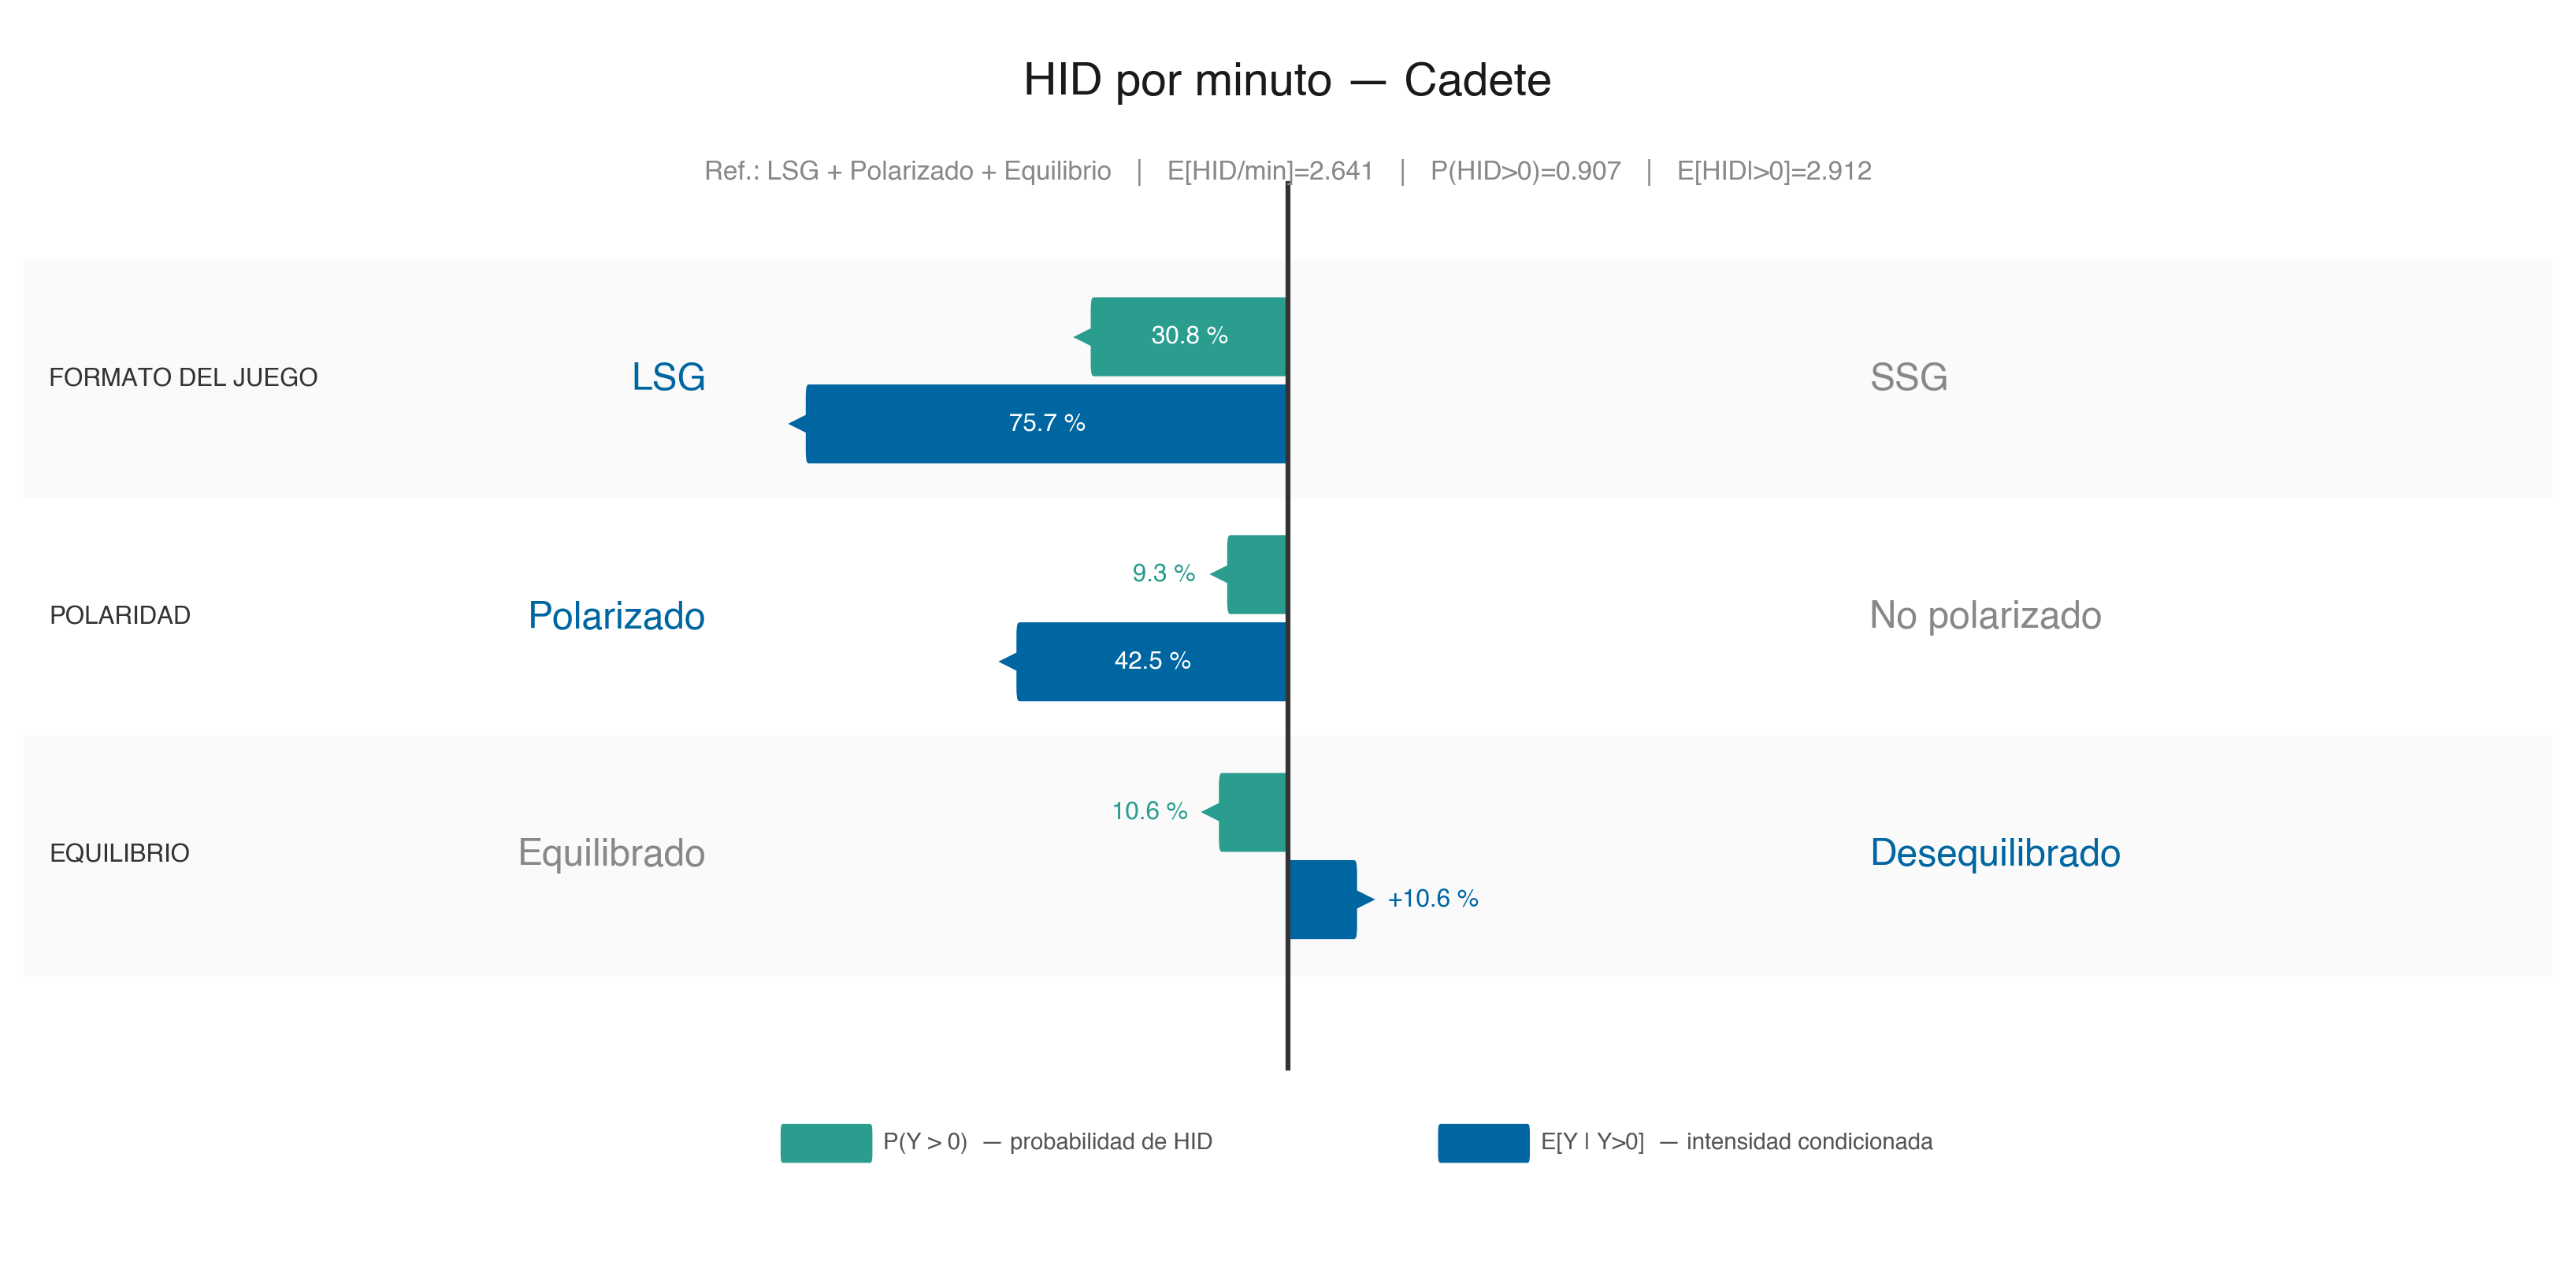

✓ Cadete guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Cadete.png


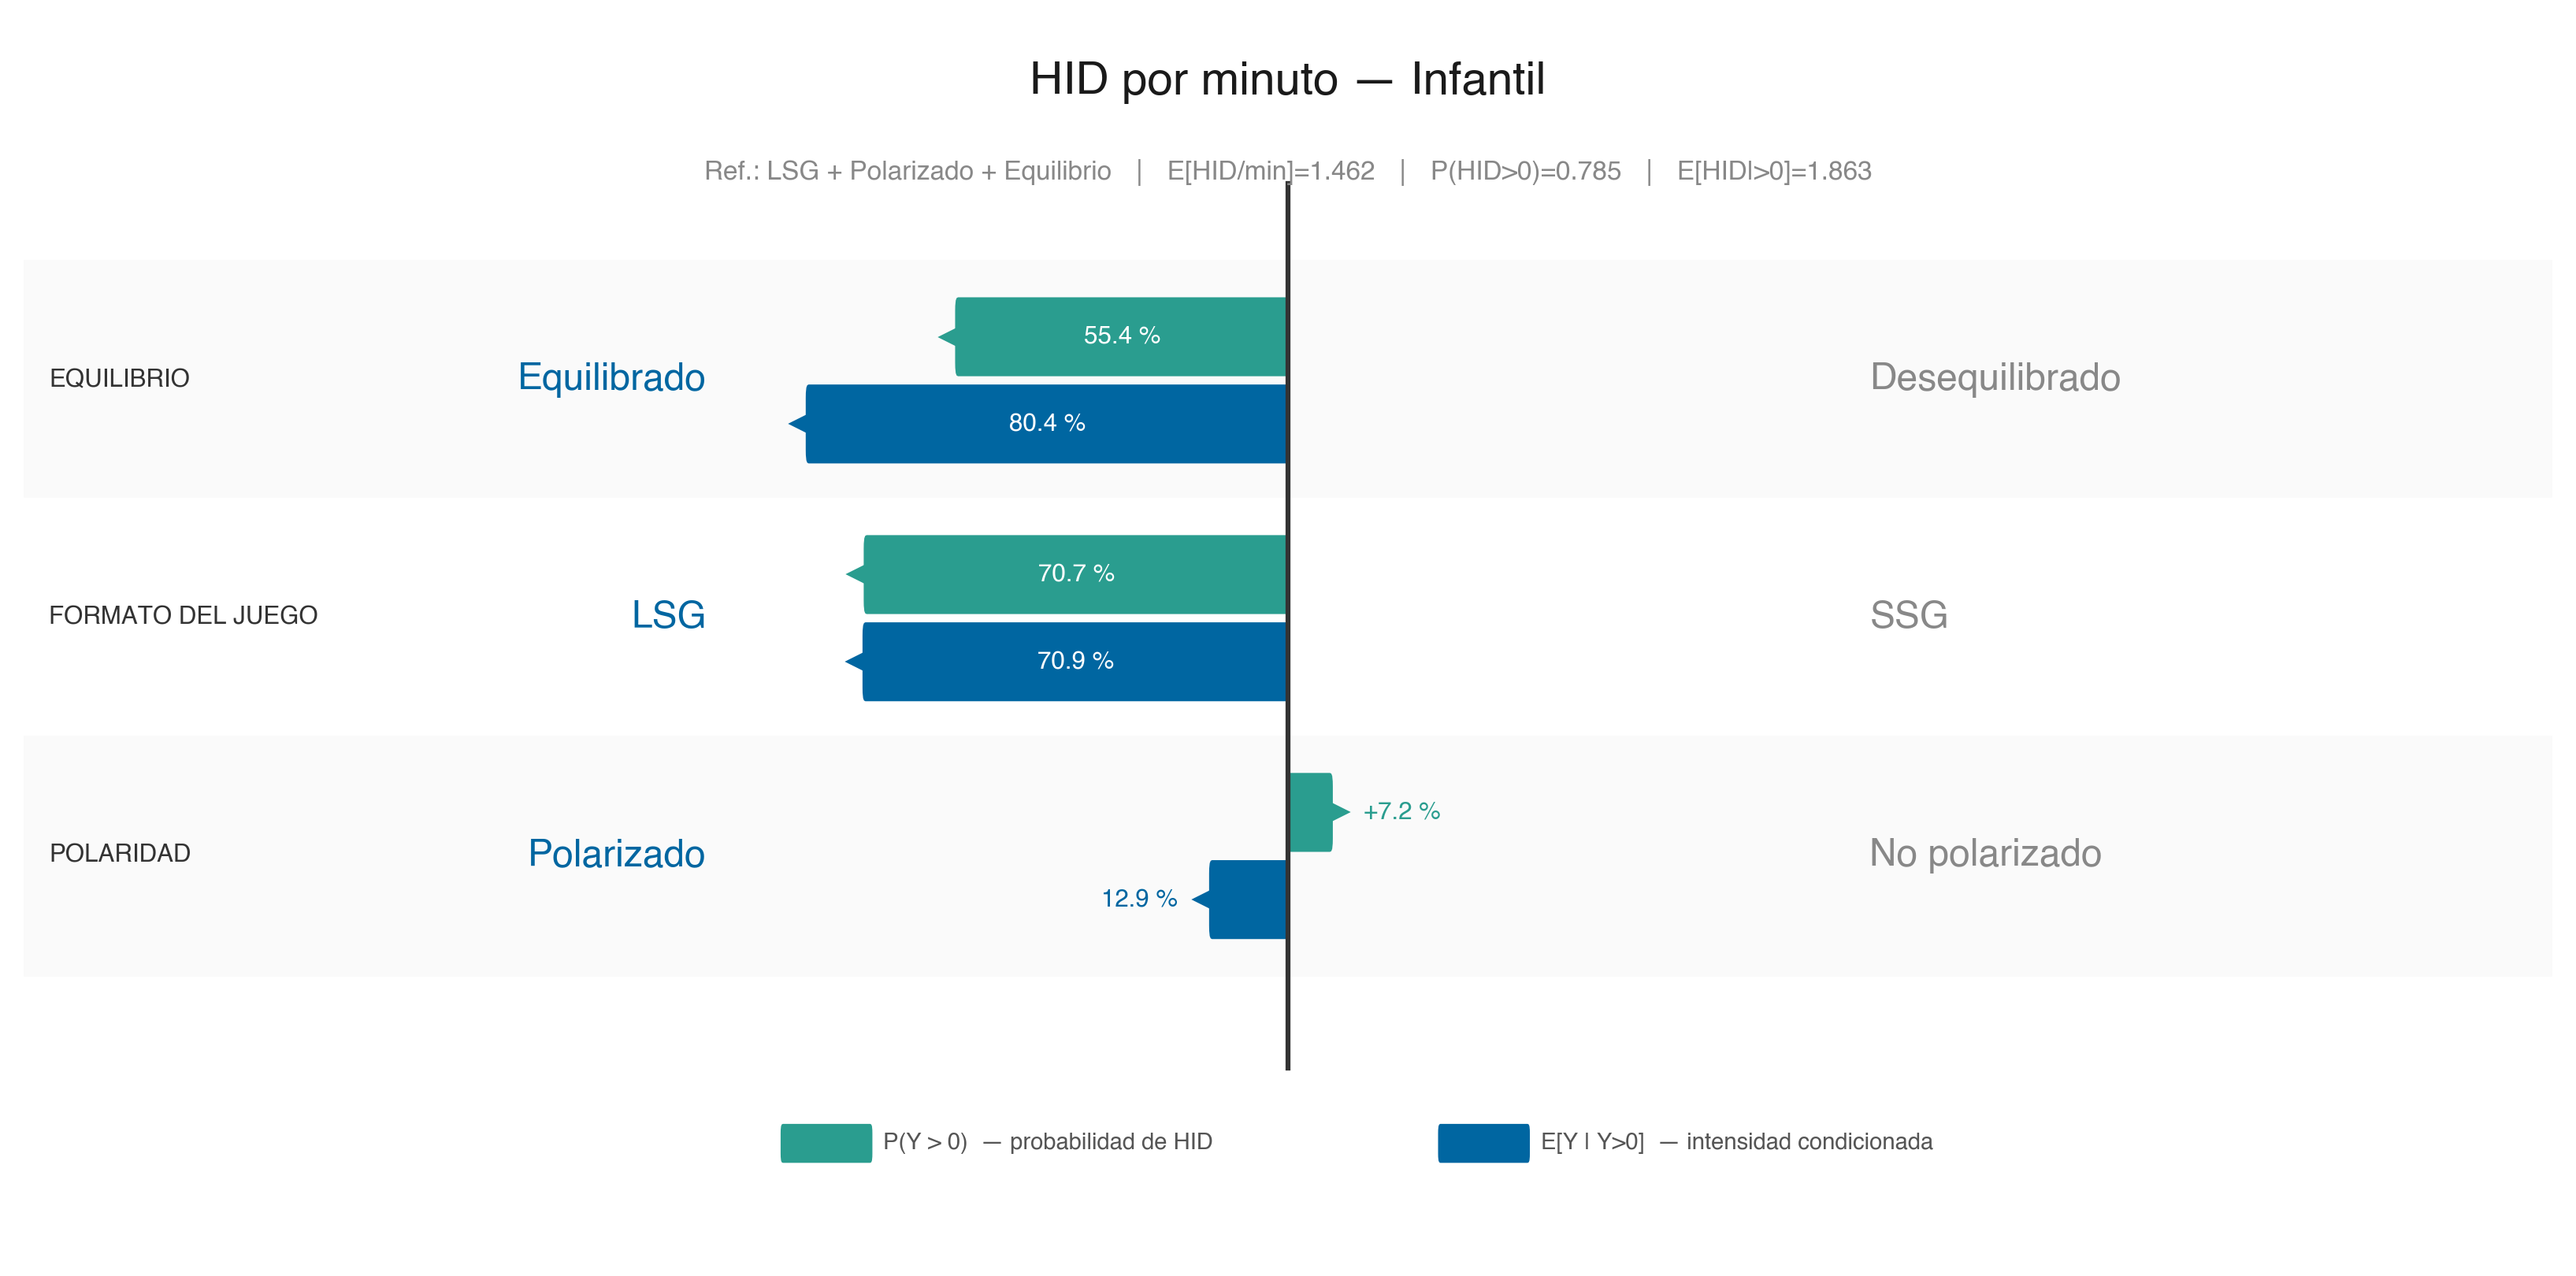

✓ Infantil guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Infantil.png


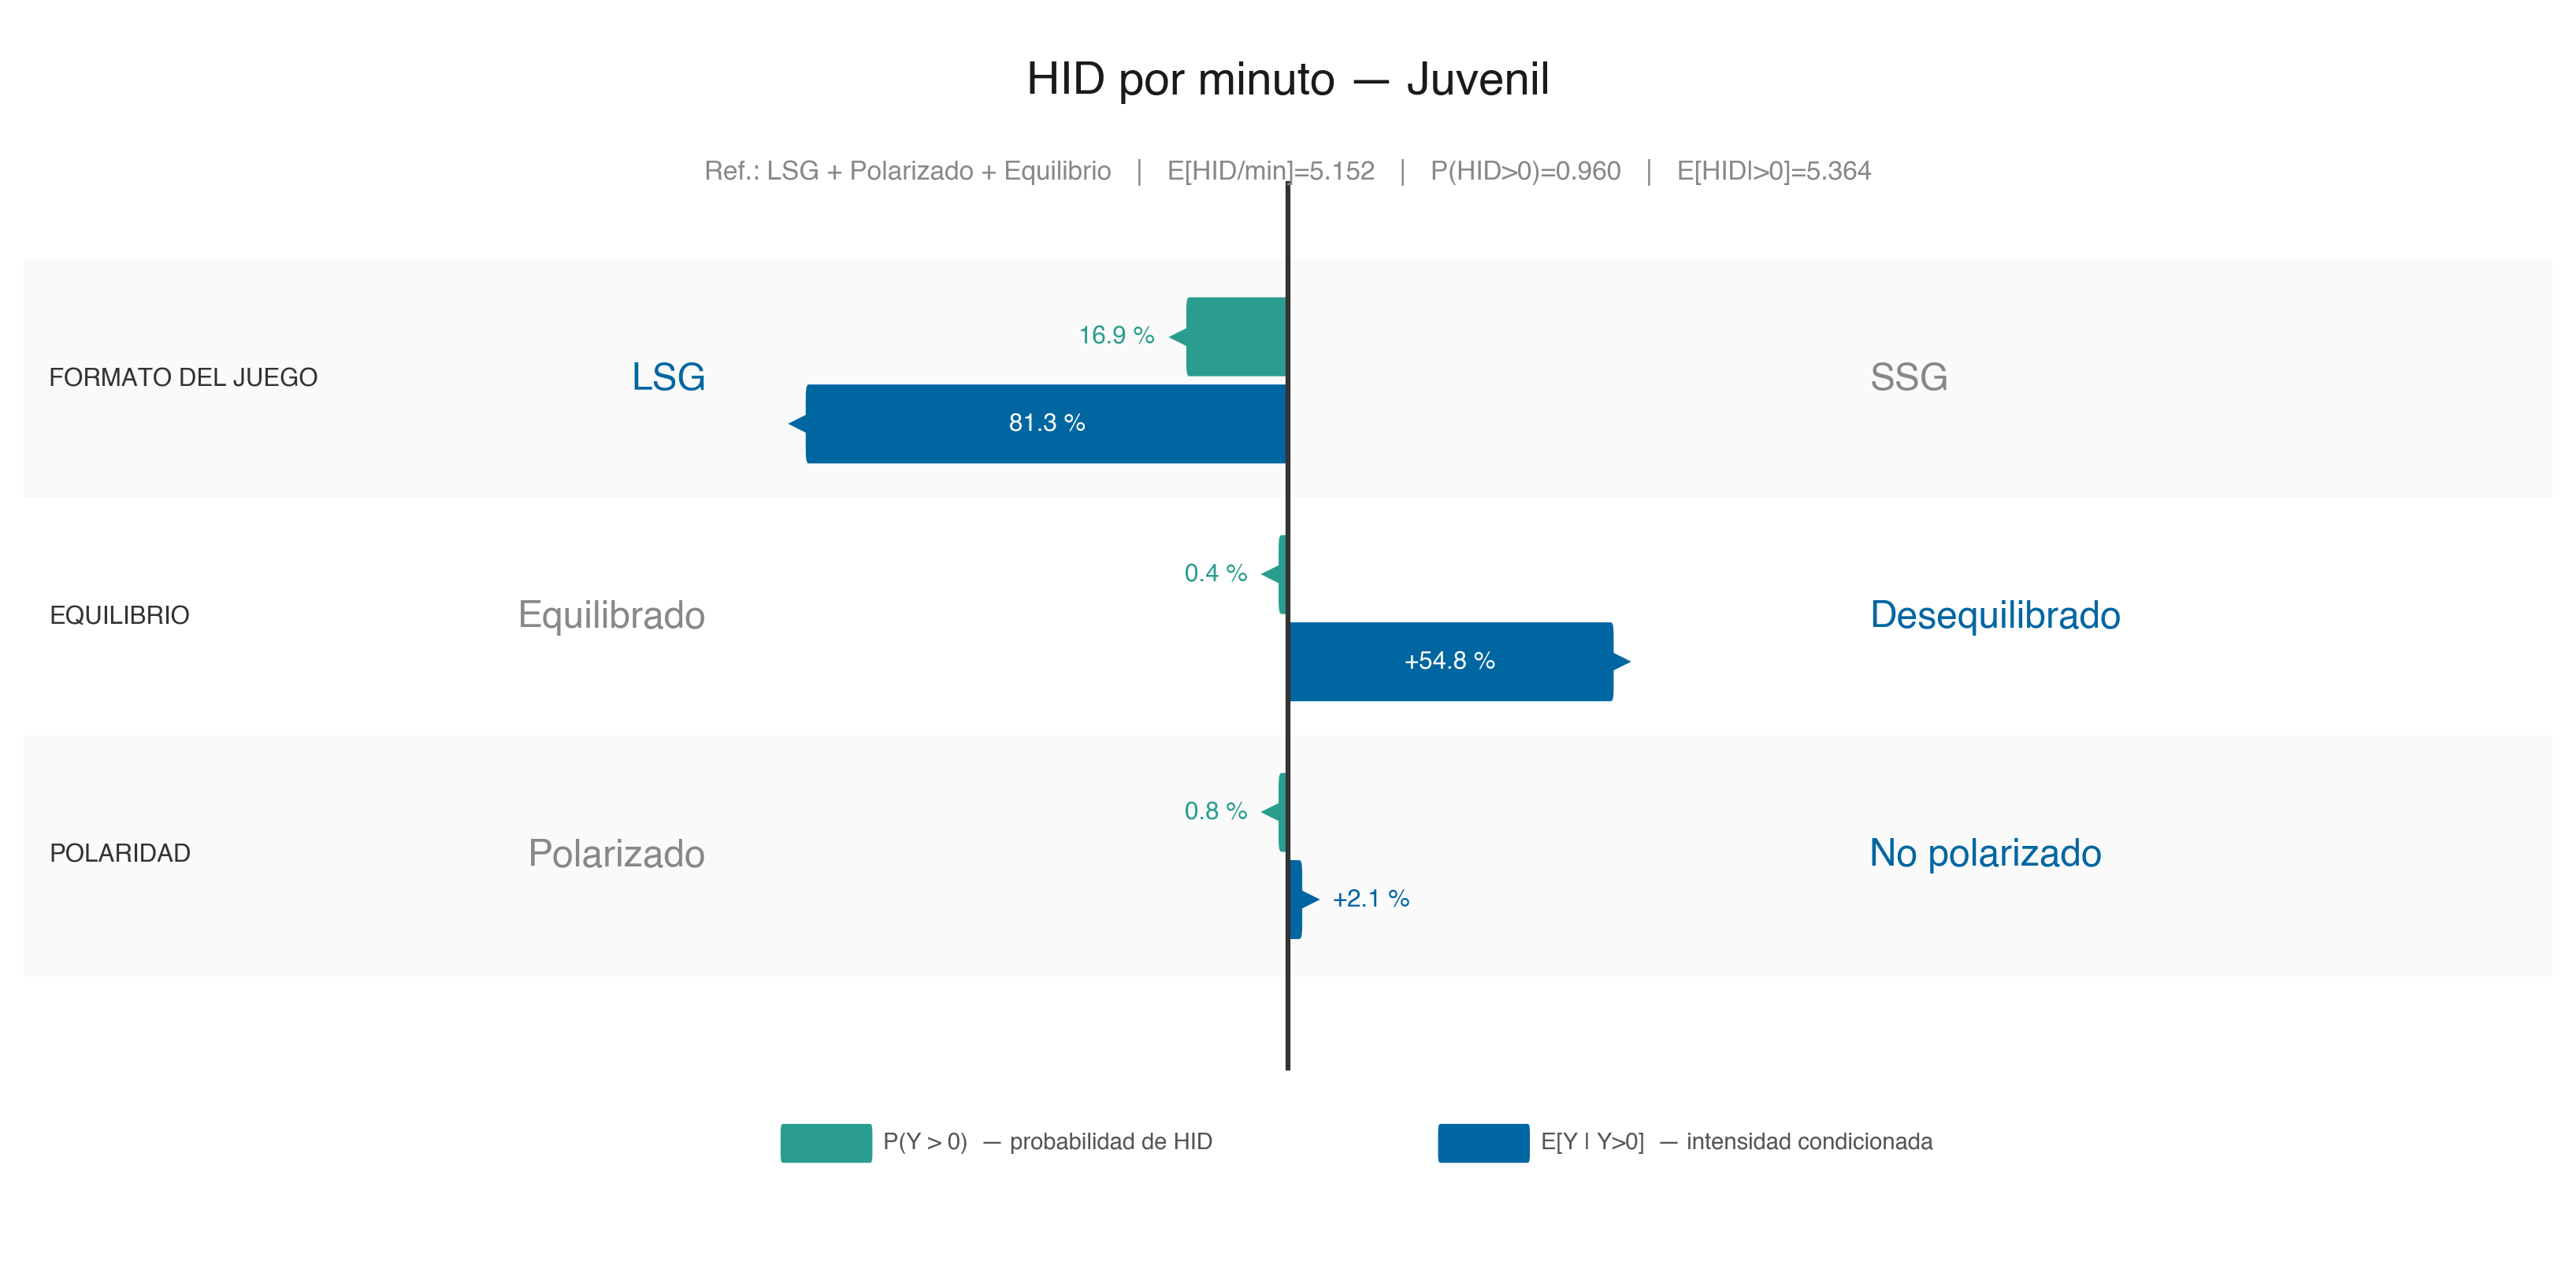

✓ Juvenil guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Juvenil.png


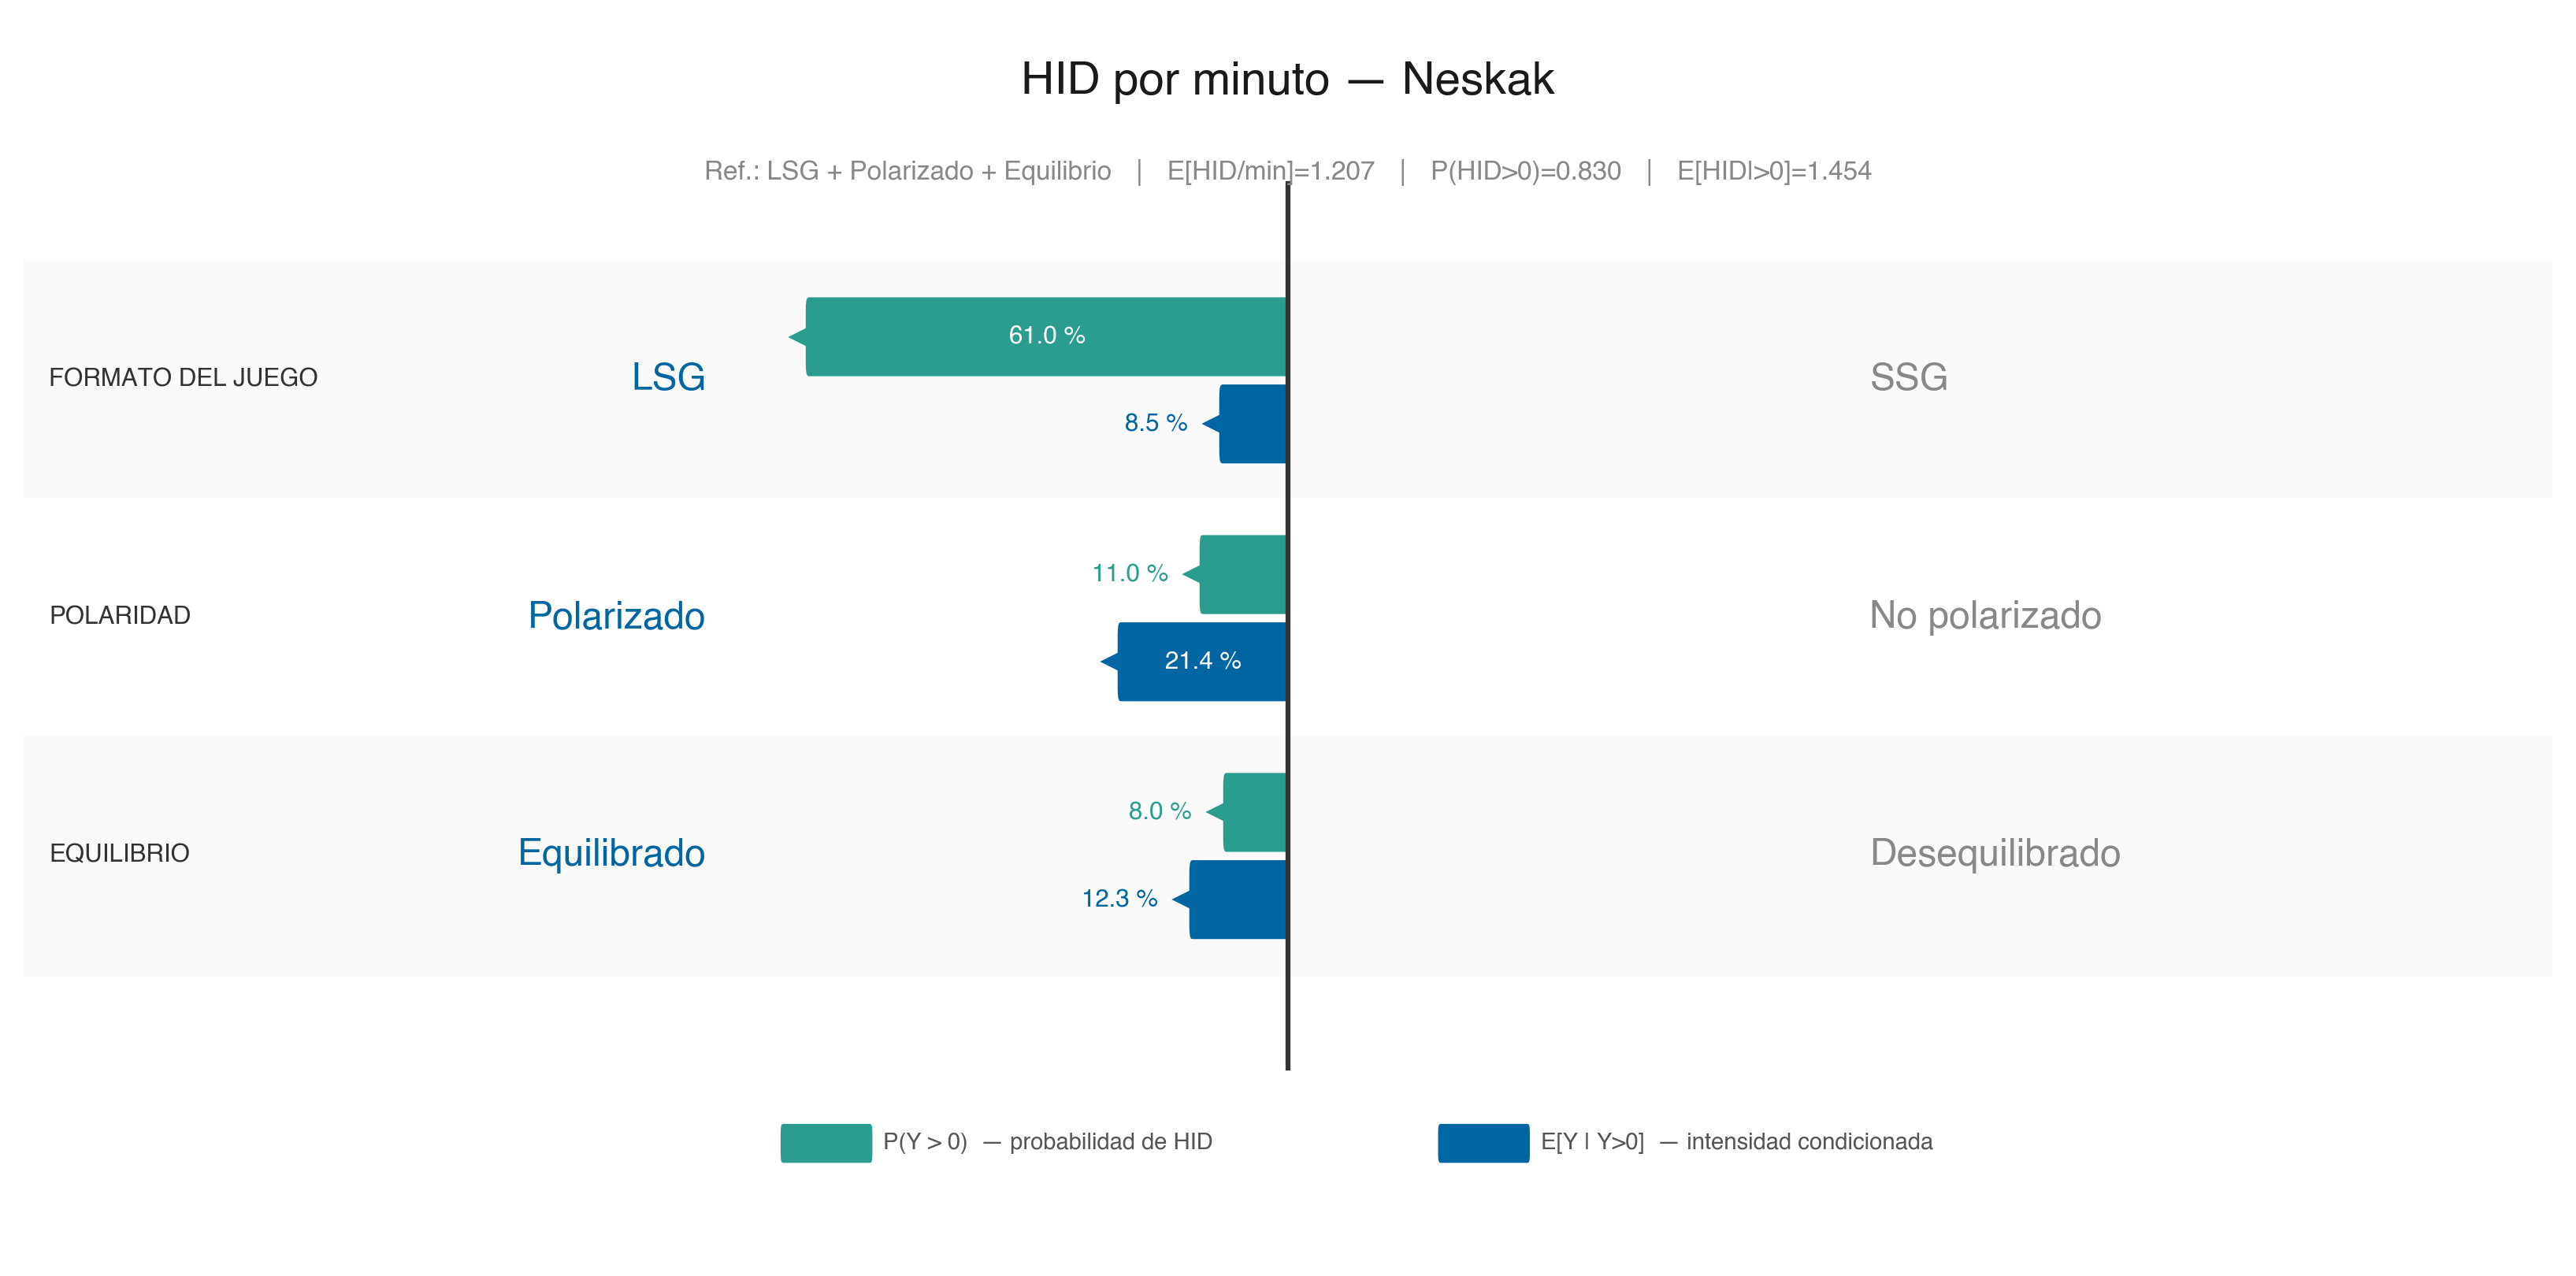

✓ Neskak guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Neskak.png


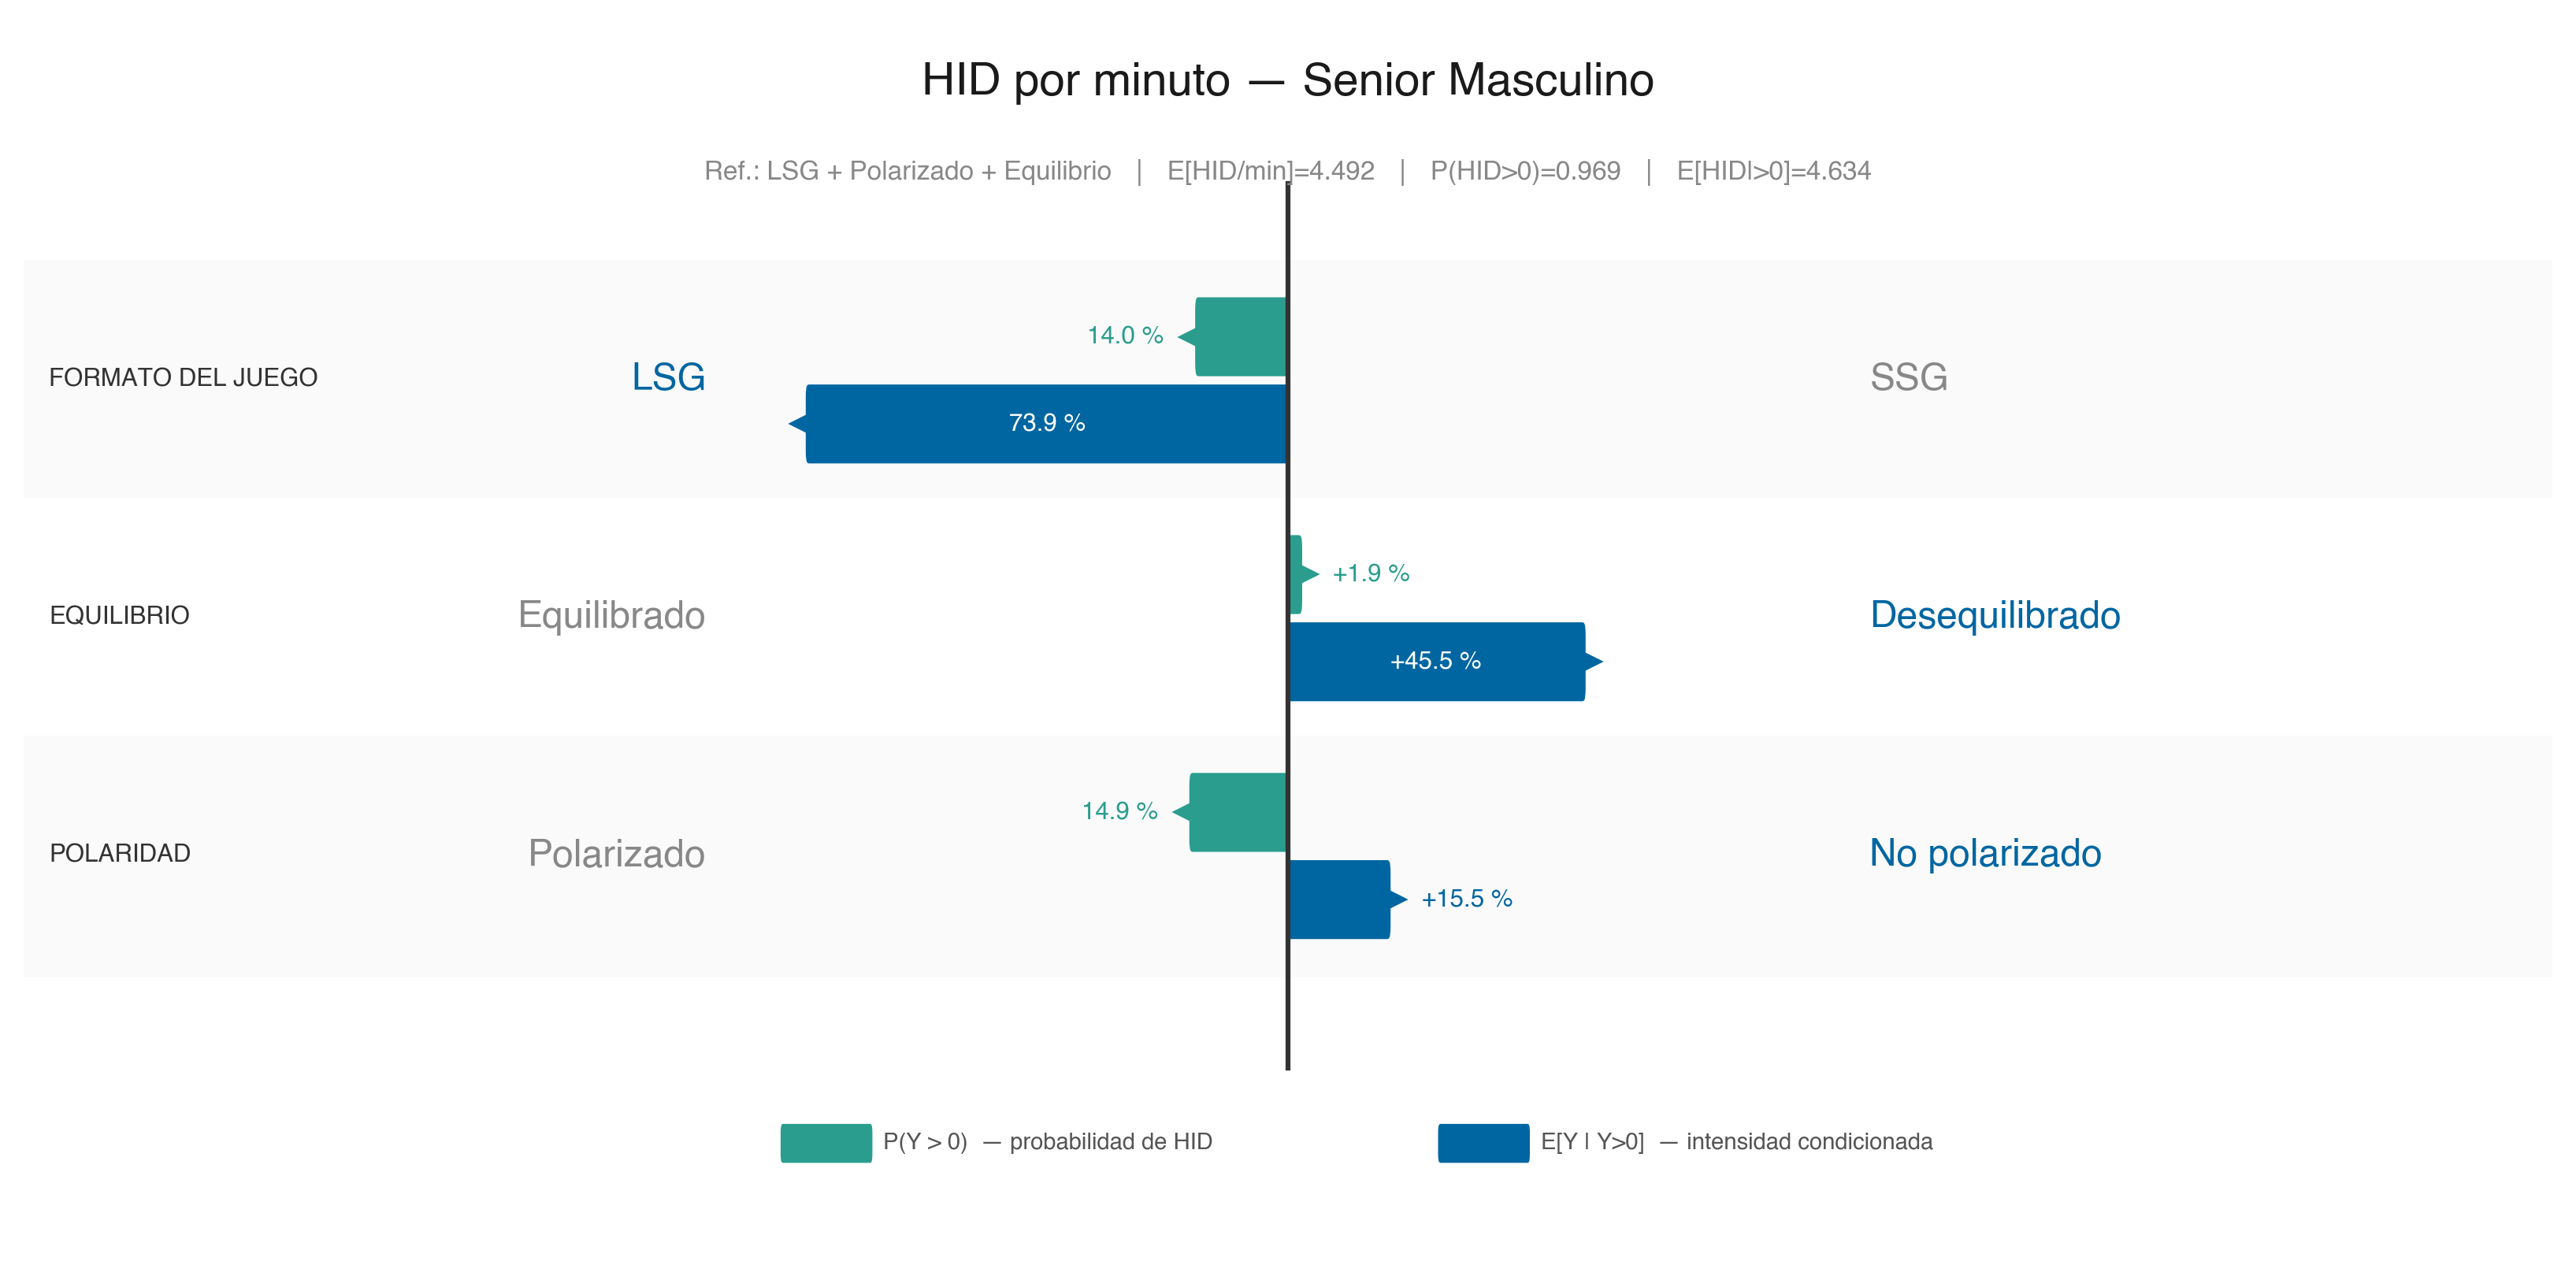

✓ Senior Masculino guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Senior_Masculino.png

Todos los gráficos generados.


In [1]:
# ═══════════════════════════════════════════════════════════════════
# VARIANTE F — Barra divergente doble · Hurdle Gamma
#              (HID / min)  — UN GRÁFICO POR GRUPO DE EDAD
#              Datos extraídos de Tablas 1-3 del notebook 04_glmm_HID
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import os

# ── Colores ──────────────────────────────────────────────────────
BLUE_MU  = "#0066A1"
TEAL_PSI = "#2A9D8F"
GREY     = "#AAAAAA"
FONT     = ["Helvetica", "Arial", "DejaVu Sans"]

# ── Datos de las Tablas 1 (E[Y]), 2 (P(Y>0)=psi) y 3 (E[Y|Y>0]=mu) ──
# Referencia base: LSG + Polarizado + Equilibrio
# Δ = impacto al cambiar desde la referencia:
#   Formato:    LSG → SSG
#   Polaridad:  Polarizado → No_polarizado
#   Equilibrio: Equilibrio → Desequilibrio
grupos = {
    "Cadete": {
        "E_ref": 2.641, "P_ref": 0.907, "mu_ref": 2.912,
        "psi": {"Formato del Juego": -30.8, "Polaridad": -9.3,  "Equilibrio": -10.6},
        "mu":  {"Formato del Juego": -75.7, "Polaridad": -42.5, "Equilibrio": +10.6},
    },
    "Infantil": {
        "E_ref": 1.462, "P_ref": 0.785, "mu_ref": 1.863,
        "psi": {"Formato del Juego": -70.7, "Polaridad": +7.2,  "Equilibrio": -55.4},
        "mu":  {"Formato del Juego": -70.9, "Polaridad": -12.9, "Equilibrio": -80.4},
    },
    "Juvenil": {
        "E_ref": 5.152, "P_ref": 0.960, "mu_ref": 5.364,
        "psi": {"Formato del Juego": -16.9, "Polaridad": -0.8,  "Equilibrio": -0.4},
        "mu":  {"Formato del Juego": -81.3, "Polaridad": +2.1,  "Equilibrio": +54.8},
    },
    "Neskak": {
        "E_ref": 1.207, "P_ref": 0.830, "mu_ref": 1.454,
        "psi": {"Formato del Juego": -61.0, "Polaridad": -11.0, "Equilibrio": -8.0},
        "mu":  {"Formato del Juego":  -8.5, "Polaridad": -21.4, "Equilibrio": -12.3},
    },
    "Senior Masculino": {
        "E_ref": 4.492, "P_ref": 0.969, "mu_ref": 4.634,
        "psi": {"Formato del Juego": -14.0, "Polaridad": -14.9, "Equilibrio": +1.9},
        "mu":  {"Formato del Juego": -73.9, "Polaridad": +15.5, "Equilibrio": +45.5},
    },
}

# Etiquetas ref/alt por variable
var_labels = {
    "Formato del Juego": ("LSG", "SSG"),
    "Polaridad":         ("Polarizado", "No polarizado"),
    "Equilibrio":        ("Equilibrado", "Desequilibrado"),
}

# ── Directorio de salida ─────────────────────────────────────────
OUT_DIR = "../Graficos/grupoedad_HID"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Geometría (igual que la Variante F base) ─────────────────────
LEFT_END    = 28
CENTER      = 50
RIGHT_START = 72
bar_reach   = 19      # px normalizado máximo por componente
sub_h       = 0.38
sub_gap     = 0.06
row_sp      = 1.20

# ── Bucle principal: un gráfico por grupo ────────────────────────
for grupo, d in grupos.items():

    # Construir filas ordenadas por |efecto| mayor
    rows = []
    for var in ["Formato del Juego", "Polaridad", "Equilibrio"]:
        pct_psi = d["psi"][var]
        pct_mu  = d["mu"][var]
        rows.append({
            "var":     var,
            "ref":     var_labels[var][0],
            "alt":     var_labels[var][1],
            "pct_psi": pct_psi, "abs_psi": abs(pct_psi),
            "dir_psi": "right" if pct_psi >= 0 else "left",
            "pct_mu":  pct_mu,  "abs_mu":  abs(pct_mu),
            "dir_mu":  "right" if pct_mu  >= 0 else "left",
            "max_abs": max(abs(pct_psi), abs(pct_mu)),
        })
    rows.sort(key=lambda r: r["max_abs"], reverse=True)
    n = len(rows)

    max_abs_all = max(r["max_abs"] for r in rows)

    # ── Figura ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)
    ax.set_xlim(0, 100)
    ax.set_ylim(-1.8, n * row_sp + 0.8)
    ax.invert_yaxis()
    ax.set_aspect("auto")

    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Fondos alternos
    for i in range(n):
        yc = i * row_sp
        bg = "#FAFAFA" if i % 2 == 0 else "#FFFFFF"
        ax.axhspan(yc - 0.5 * row_sp, yc + 0.5 * row_sp, color=bg, zorder=0)

    # Línea central
    ax.axvline(CENTER, color="#333333", linewidth=1.5, zorder=6,
               ymin=0.15, ymax=0.87)

    # ── Dibujar filas ────────────────────────────────────────────
    for i, r in enumerate(rows):
        yc = i * row_sp

        for j, (comp, comp_col, comp_lbl) in enumerate([
            ("psi", TEAL_PSI, "P(Y>0)"),
            ("mu",  BLUE_MU,  "E[Y|Y>0]"),
        ]):
            y_bar = yc + (sub_h + sub_gap) * (j - 0.5)

            pct_abs   = r[f"abs_{comp}"]
            direction = r[f"dir_{comp}"]
            pct_val   = r[f"pct_{comp}"]

            bar_len = max((pct_abs / max_abs_all) * bar_reach, 0.3)
            x0 = CENTER if direction == "right" else CENTER - bar_len

            fancy = FancyBboxPatch(
                (x0, y_bar - sub_h / 2), bar_len, sub_h,
                boxstyle="round,pad=0,rounding_size=0.06",
                facecolor=comp_col, edgecolor=comp_col,
                linewidth=1.1, zorder=3)
            ax.add_patch(fancy)

            # Chevron
            mk = ">" if direction == "right" else "<"
            mx = (CENTER + bar_len + 0.35) if direction == "right" else (CENTER - bar_len - 0.35)
            ax.plot(mx, y_bar, marker=mk, markersize=4.5,
                    color=comp_col, zorder=4, clip_on=False)

            # Etiqueta porcentaje
            sign_str = "+" if pct_val >= 0 else ""
            pct_txt  = f"{sign_str}{pct_abs:.1f} %"

            if bar_len > 4.0:
                ax.text(x0 + bar_len / 2, y_bar, pct_txt,
                        ha="center", va="center", fontsize=7.5,
                        fontweight="bold", color="white", zorder=5, fontfamily=FONT)
            else:
                if direction == "right":
                    ax.text(CENTER + bar_len + 1.3, y_bar, pct_txt,
                            ha="left", va="center", fontsize=7.5,
                            fontweight="bold", color=comp_col, zorder=5, fontfamily=FONT)
                else:
                    ax.text(CENTER - bar_len - 1.3, y_bar, pct_txt,
                            ha="right", va="center", fontsize=7.5,
                            fontweight="bold", color=comp_col, zorder=5, fontfamily=FONT)

        # ── Etiquetas ref/alt ────────────────────────────────────
        # Ganador en negrita (el componente mu manda para el color)
        if r["dir_mu"] == "left":
            left_col, left_wt   = BLUE_MU,  "bold"
            right_col, right_wt = "#888888", "normal"
        else:
            left_col, left_wt   = "#888888", "normal"
            right_col, right_wt = BLUE_MU,  "bold"

        ax.text(LEFT_END - 1, yc, r["ref"],
                ha="right", va="center", fontsize=11.5,
                color=left_col, fontweight=left_wt, fontfamily=FONT)
        ax.text(RIGHT_START + 1, yc, r["alt"],
                ha="left", va="center", fontsize=11.5,
                color=right_col, fontweight=right_wt, fontfamily=FONT)

        # Nombre variable (extremo izquierdo)
        ax.text(1, yc, r["var"].upper(),
                ha="left", va="center", fontsize=7.5,
                color="#333333", fontweight="medium", fontfamily=FONT)

    # ── Leyenda ──────────────────────────────────────────────────
    leg_y = n * row_sp + 0.25

    p1 = FancyBboxPatch(
        (CENTER - 20, leg_y - 0.09), 3.5, 0.18,
        boxstyle="round,pad=0,rounding_size=0.04",
        facecolor=TEAL_PSI, edgecolor=TEAL_PSI, linewidth=1, zorder=3)
    ax.add_patch(p1)
    ax.text(CENTER - 16, leg_y, "P(Y > 0)  — probabilidad de HID",
            ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

    p2 = FancyBboxPatch(
        (CENTER + 6, leg_y - 0.09), 3.5, 0.18,
        boxstyle="round,pad=0,rounding_size=0.04",
        facecolor=BLUE_MU, edgecolor=BLUE_MU, linewidth=1, zorder=3)
    ax.add_patch(p2)
    ax.text(CENTER + 10, leg_y, "E[Y | Y>0]  — intensidad condicionada",
            ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

    # ── Título ───────────────────────────────────────────────────
    ax.text(CENTER, -1.5,
            f"HID por minuto — {grupo}",
            ha="center", va="center", fontsize=14, fontweight="bold",
            color="#1a1a1a", fontfamily=FONT, zorder=10)
    ax.text(CENTER, -1.05,
            f"Ref.: LSG + Polarizado + Equilibrio  │  "
            f"E[HID/min]={d['E_ref']:.3f}  │  P(HID>0)={d['P_ref']:.3f}  │  "
            f"E[HID|>0]={d['mu_ref']:.3f}",
            ha="center", va="center", fontsize=8, color="#888888",
            fontstyle="italic", fontfamily=FONT, zorder=10)

    fig.patch.set_facecolor("white")
    fig.tight_layout()

    # Guardar
    fname = grupo.replace(" ", "_")
    fig.savefig(f"{OUT_DIR}/HID_grupoedad_{fname}.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ {grupo} guardado en {OUT_DIR}/HID_grupoedad_{fname}.png")

print("\nTodos los gráficos generados.")


# 05 — Gráficos de resultados GLMM

Forest plots horizontales para visualizar los efectos fijos de cada modelo GLMM bayesiano.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ---------- Estilo general ----------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Colores
BLUE_RSO = "#0066A1"   # Real Sociedad blue
GREY_NS  = "#AAAAAA"   # no significativo
BAND_CLR = "#F0F0F0"   # banda de efecto despreciable

Datos extraídos del modelo:
  Formato del Juego               LSG  →  SSG                 +77.5 %  ✓
  Polaridad           Polarizado  →  No polarizado       +32.8 %  ✓
  Equilibrio         Equilibrado  →  Desequilibrado      +2.3 %  ✗


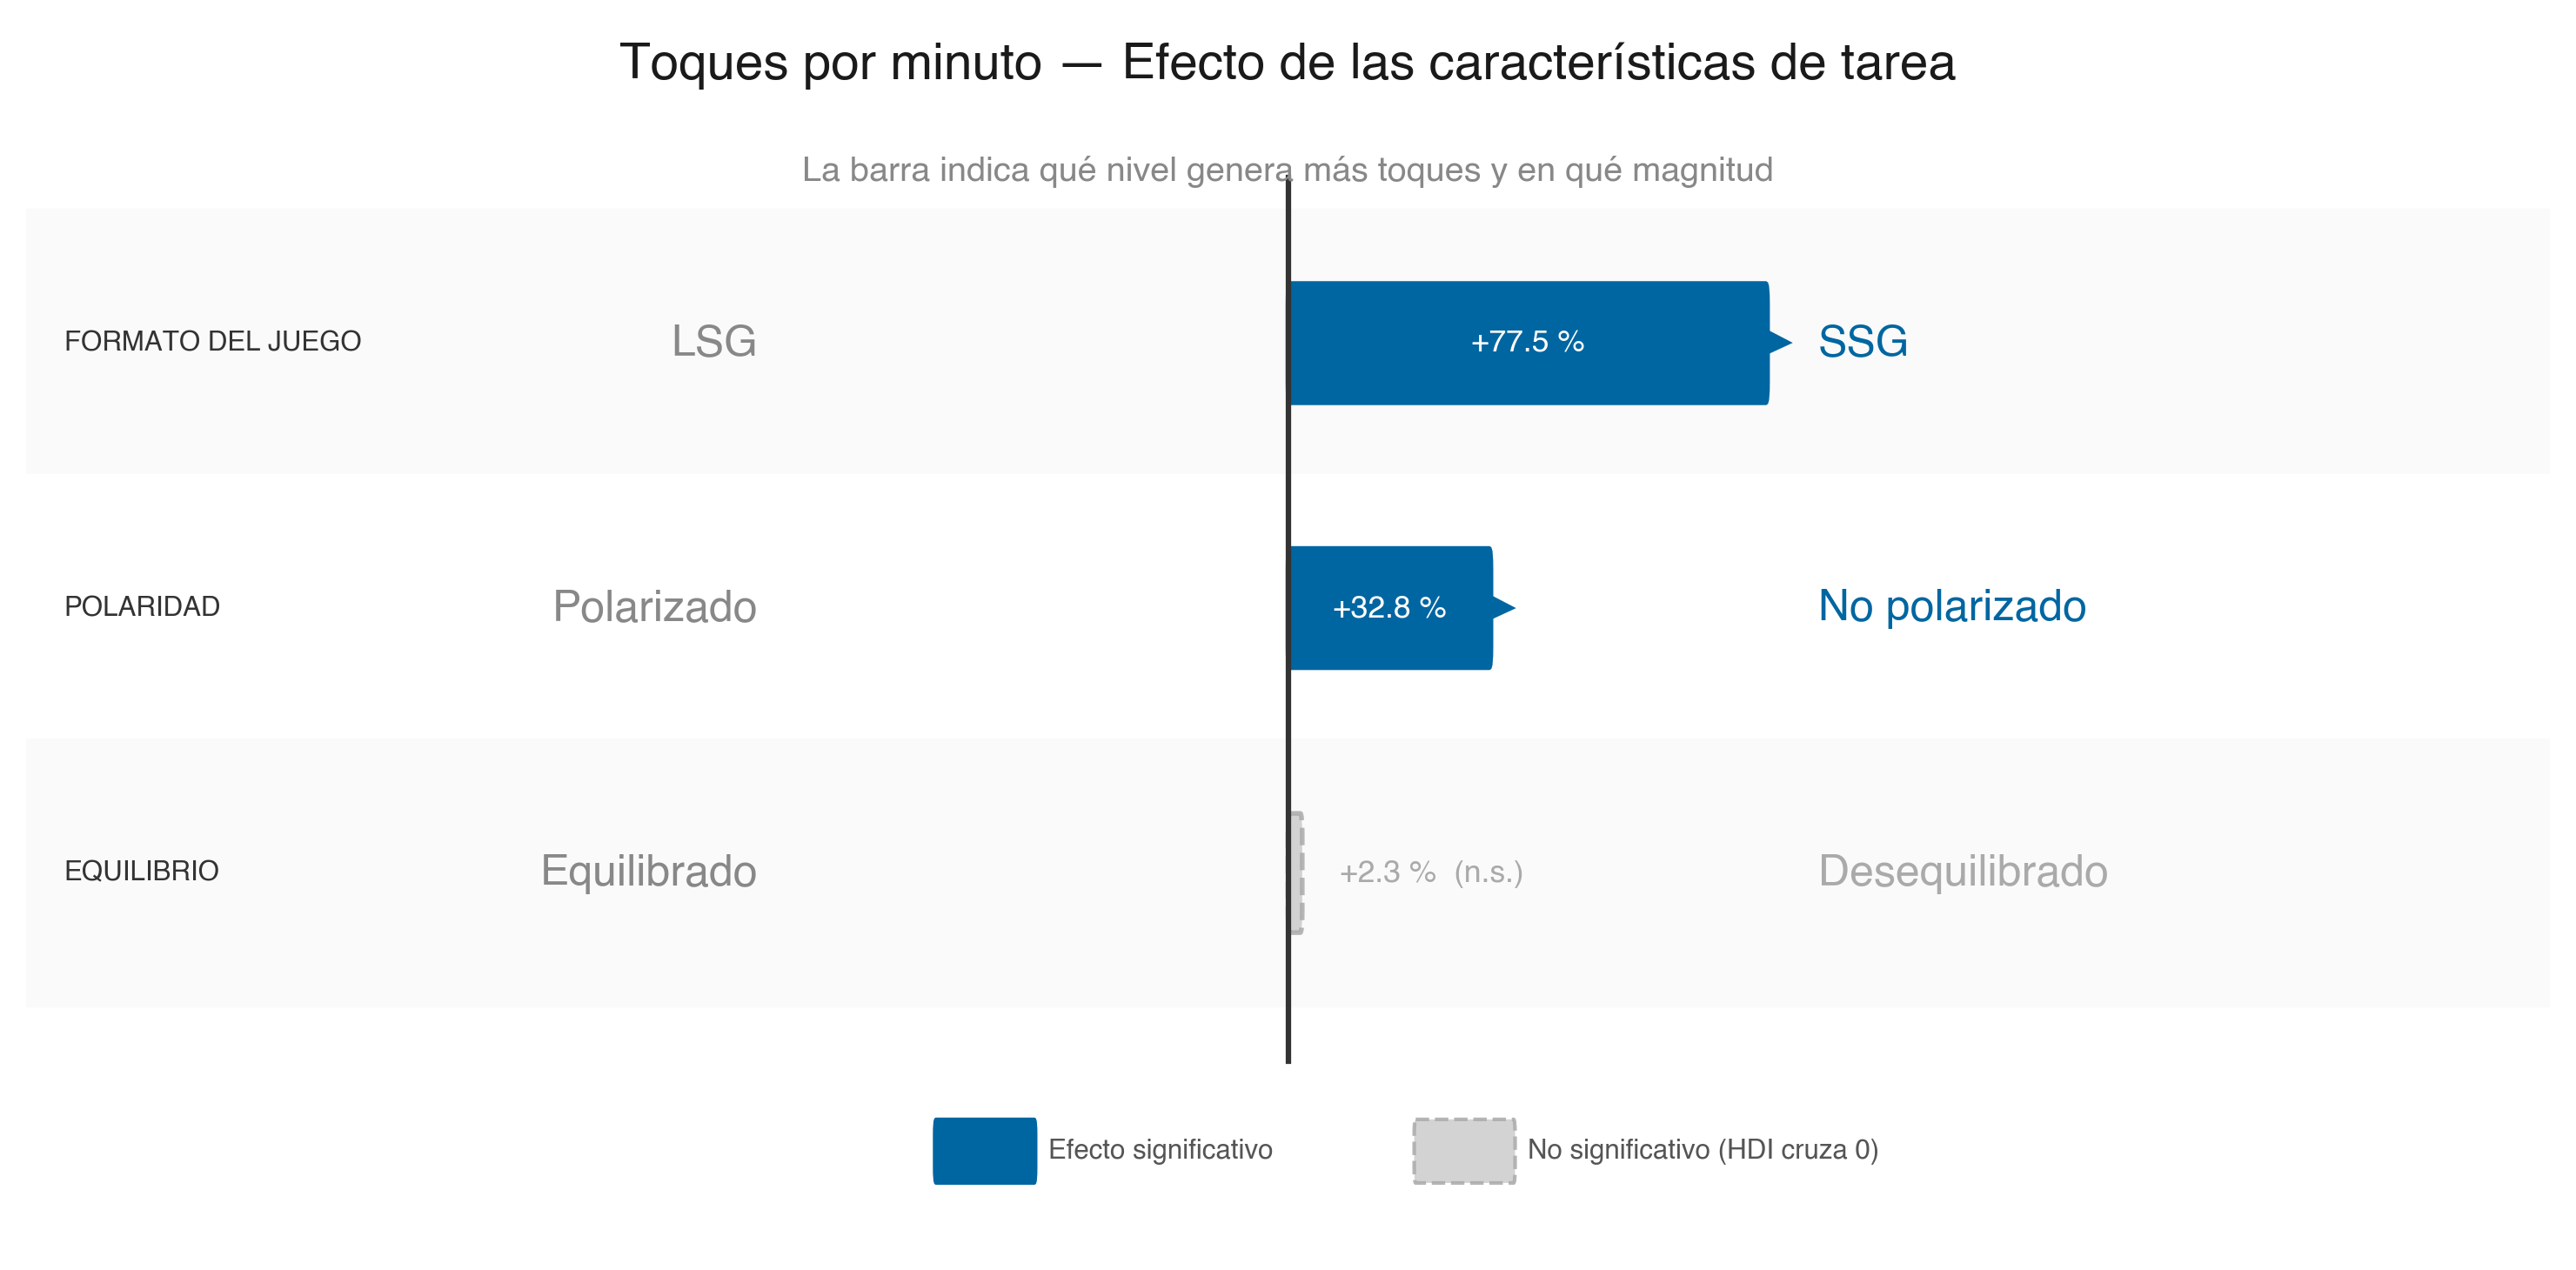

In [3]:
# ═══════════════════════════════════════════════════════════════════
# VARIANTE F — Barra divergente limpia · columnas tripartitas
#              (Toques / min)  — datos extraídos del modelo GLMM
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import arviz as az

# ── Colores ──────────────────────────────────────────────────────
BLUE   = "#0066A1"
GREY   = "#AAAAAA"
NS_BAR = "#CCCCCC"
FONT   = ["Helvetica", "Arial", "DejaVu Sans"]

# ── Cargar InferenceData del modelo final ────────────────────────
idata = az.from_netcdf("../Datos/glmm_toques_final.nc")
posterior = idata.posterior

# ── Mapa de variables ────────────────────────────────────────────
# param     : nombre exacto en el posterior (Bambi)
# ref_label : nivel de referencia para la presentación
# alt_label : nivel alternativo
# flip      : True si la ref. alfabética de Bambi ≠ ref. de presentación
#             → Polaridad: Bambi ref = "No polarizado", present. ref = "Polarizado"  → flip
#             → Equilibrio: Bambi ref = "Desequilibrio", present. ref = "Equilibrio" → flip
var_map = [
    {"var": "Polaridad",  "param": "Polaridad",  "ref_label": "Polarizado",   "alt_label": "No polarizado",  "flip": True},
    {"var": "Formato del Juego", "param": "Formato_del_Juego", "ref_label": "LSG", "alt_label": "SSG", "flip": False},
    {"var": "Equilibrio", "param": "Equilibrio",  "ref_label": "Equilibrado",  "alt_label": "Desequilibrado", "flip": True},
]

# ── Extraer efectos fijos del posterior ──────────────────────────
rows_f = []
for v in var_map:
    beta = posterior[v["param"]].values.flatten()
    if v["flip"]:
        beta = -beta

    # Cambio porcentual: Gamma log-link → (exp(β) − 1) × 100
    pct_samples = (np.exp(beta) - 1) * 100
    pct_median  = float(np.median(pct_samples))

    # Significativo si el HDI 95 % del β no cruza 0
    hdi = az.hdi(beta, prob=0.95)
    sig = not (hdi[0] <= 0 <= hdi[1])

    # Determinar ganador (positivo → el nivel alternativo gana)
    if pct_median >= 0:
        left_label, right_label = v["ref_label"], v["alt_label"]
    else:
        left_label, right_label = v["alt_label"], v["ref_label"]
        pct_median = abs(pct_median)

    rows_f.append({
        "var": v["var"],
        "left": left_label,
        "right": right_label,
        "pct": round(pct_median, 1),
        "sig": sig,
    })

# Ordenar por tamaño de efecto (mayor primero)
rows_f.sort(key=lambda r: r["pct"], reverse=True)
n_f = len(rows_f)

print("Datos extraídos del modelo:")
for r in rows_f:
    tag = "✓" if r["sig"] else "✗"
    print(f"  {r['var']:12s}  {r['left']:>16s}  →  {r['right']:<18s}  "
          f"+{r['pct']:.1f} %  {tag}")

# ── Geometría (unidades normalizadas) ────────────────────────────
#    x ∈ [0, 100]:  col-izq [0,30], centro [30,70], col-der [70,100]
LEFT_END    = 30
CENTER      = 50
RIGHT_START = 70
max_pct_f   = max(r["pct"] for r in rows_f)
bar_reach   = 19          # max bar ≈ 95 % del medio-ancho

bar_h_f = 0.45

# ── Figura ───────────────────────────────────────────────────────
fig_f, ax_f = plt.subplots(figsize=(10, 5), dpi=300)
ax_f.set_xlim(0, 100)
ax_f.set_ylim(-1.2, n_f + 0.4)
ax_f.invert_yaxis()
ax_f.set_aspect("auto")

for sp in ax_f.spines.values():
    sp.set_visible(False)
ax_f.set_xticks([])
ax_f.set_yticks([])

# ── Fondos alternos ──────────────────────────────────────────────
for i in range(n_f):
    bg_color = "#FAFAFA" if i % 2 == 0 else "#FFFFFF"
    ax_f.axhspan(i - 0.5, i + 0.5, color=bg_color, zorder=0)

# ── Línea central ────────────────────────────────────────────────
ax_f.axvline(CENTER, color="#333333", linewidth=1.5, zorder=6,
             ymin=0.15, ymax=0.875)

# ── Dibujar filas ────────────────────────────────────────────────
for i, r in enumerate(rows_f):
    y = i
    bar_len = (r["pct"] / max_pct_f) * bar_reach

    if r["sig"]:
        bar_col, edge_col, ls_style, alpha_f = BLUE, BLUE, "-", 1.0
    else:
        bar_col, edge_col, ls_style, alpha_f = NS_BAR, GREY, "--", 0.85

    # Barra redondeada
    fancy = FancyBboxPatch(
        (CENTER, y - bar_h_f / 2), bar_len, bar_h_f,
        boxstyle="round,pad=0,rounding_size=0.08",
        facecolor=bar_col, edgecolor=edge_col,
        linewidth=1.3, linestyle=ls_style, alpha=alpha_f, zorder=3)
    ax_f.add_patch(fancy)

    # Chevron ▶ al final de barras significativas
    if r["sig"]:
        ax_f.plot(CENTER + bar_len + 0.4, y, marker=">", markersize=6,
                  color=BLUE, zorder=4, clip_on=False)

    # Porcentaje
    pct_label = f"+{r['pct']:.1f} %"
    if not r["sig"]:
        pct_label += "  (n.s.)"

    if bar_len > 3.5:
        ax_f.text(CENTER + bar_len / 2, y, pct_label,
                  ha="center", va="center", fontsize=8.5,
                  fontweight="bold", color="white", zorder=5, fontfamily=FONT)
    else:
        ax_f.text(CENTER + bar_len + 1.5, y, pct_label,
                  ha="left", va="center", fontsize=8.5,
                  fontweight="bold", color=edge_col, zorder=5, fontfamily=FONT)

    # Etiqueta izquierda (nivel perdedor)
    ax_f.text(LEFT_END - 1, y, r["left"],
              ha="right", va="center", fontsize=12,
              color="#888888", fontfamily=FONT)

    # Etiqueta derecha (nivel ganador)
    right_col = BLUE if r["sig"] else GREY
    right_wt  = "bold" if r["sig"] else "normal"
    ax_f.text(RIGHT_START + 1, y, r["right"],
              ha="left", va="center", fontsize=12,
              color=right_col, fontweight=right_wt, fontfamily=FONT)

    # Nombre de variable (extremo izquierdo)
    ax_f.text(1.5, y, r["var"].upper(),
              ha="left", va="center", fontsize=7.5,
              color="#333333", fontweight="medium", fontfamily=FONT)

# ── Leyenda inferior ─────────────────────────────────────────────
leg_y = n_f + 0.05

sig_patch = FancyBboxPatch(
    (CENTER - 14, leg_y - 0.12), 4, 0.24,
    boxstyle="round,pad=0,rounding_size=0.06",
    facecolor=BLUE, edgecolor=BLUE, linewidth=1, zorder=3)
ax_f.add_patch(sig_patch)
ax_f.text(CENTER - 9.5, leg_y, "Efecto significativo",
          ha="left", va="center", fontsize=7.5, color="#555555", fontfamily=FONT)

ns_patch = FancyBboxPatch(
    (CENTER + 5, leg_y - 0.12), 4, 0.24,
    boxstyle="round,pad=0,rounding_size=0.06",
    facecolor=NS_BAR, edgecolor=GREY, linewidth=1,
    linestyle="--", alpha=0.85, zorder=3)
ax_f.add_patch(ns_patch)
ax_f.text(CENTER + 9.5, leg_y, "No significativo (HDI cruza 0)",
          ha="left", va="center", fontsize=7.5, color="#555555", fontfamily=FONT)

# ── Título y subtítulo ───────────────────────────────────────────
ax_f.text(CENTER, -1.05,
          "Toques por minuto — Efecto de las características de tarea",
          ha="center", va="center", fontsize=14, fontweight="bold",
          color="#1a1a1a", fontfamily=FONT, zorder=10)
ax_f.text(CENTER, -0.65,
          "La barra indica qué nivel genera más toques y en qué magnitud",
          ha="center", va="center", fontsize=9.5, color="#888888",
          fontstyle="italic", fontfamily=FONT, zorder=10)

fig_f.patch.set_facecolor("white")
fig_f.tight_layout()
plt.show()

Datos extraídos del modelo (Distancia / min):
  Formato del Juego               LSG  ←  SSG                 -18.9 %  ✓
  Equilibrio         Equilibrado  ←  Desequilibrado      -8.4 %  ✓
  Polaridad           Polarizado  →  No polarizado       +6.6 %  ✗


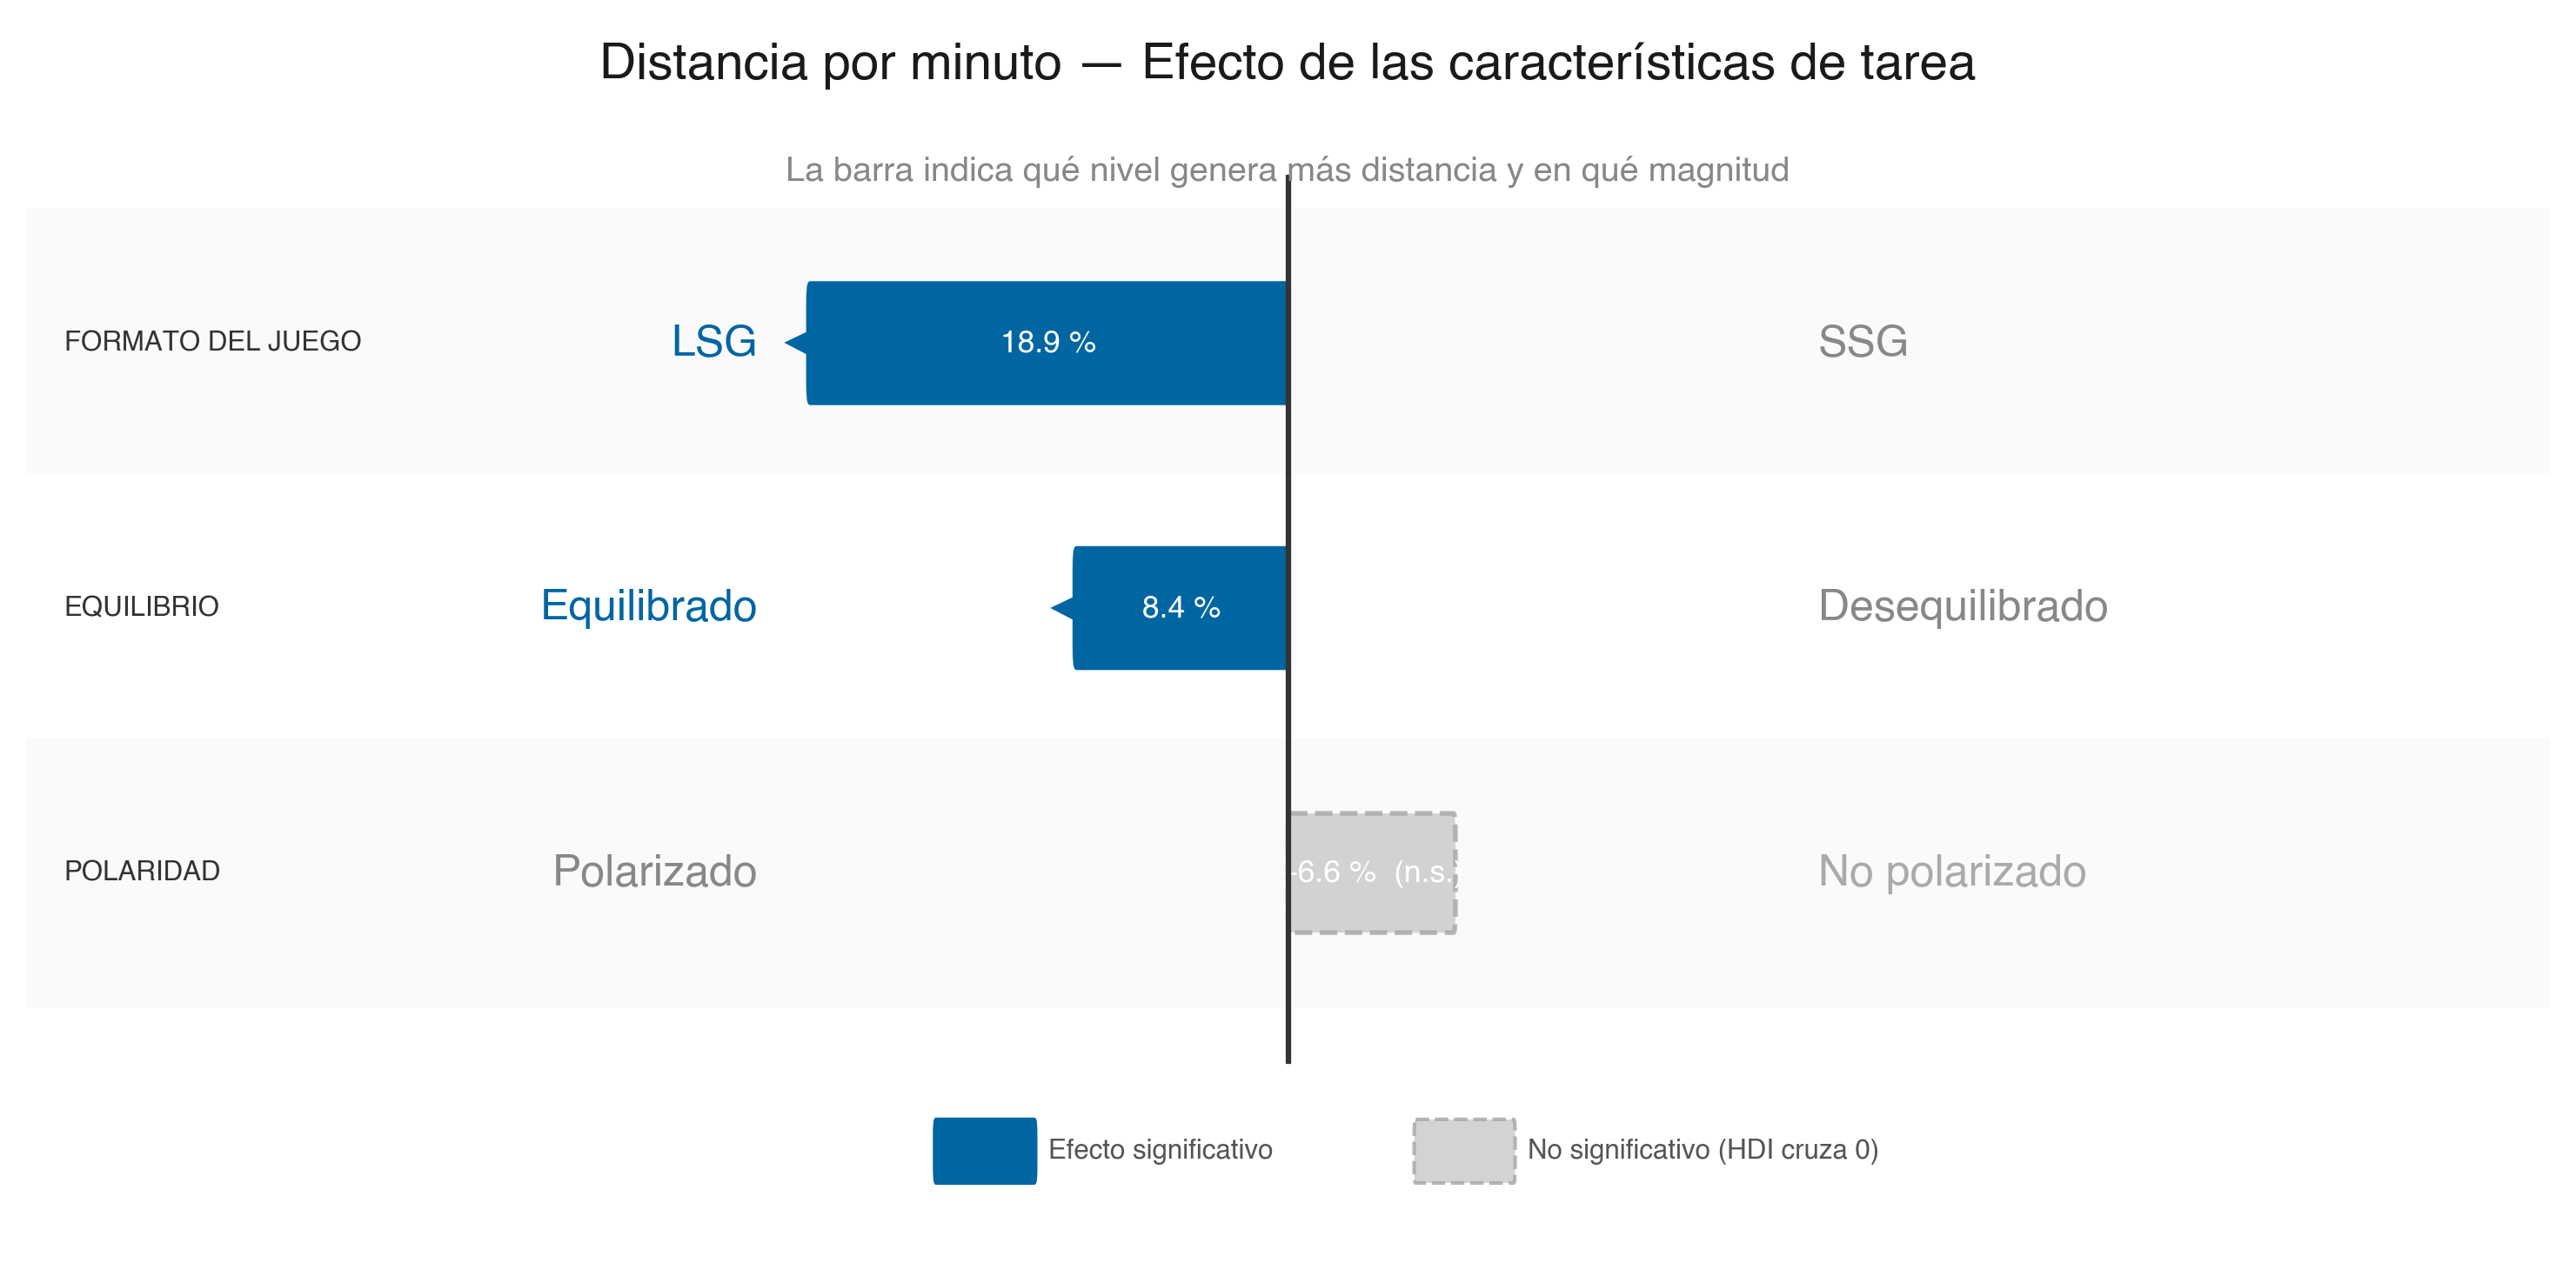

In [4]:
# ═══════════════════════════════════════════════════════════════════
# VARIANTE F — Barra divergente limpia · columnas tripartitas
#              (Distancia / min)  — datos extraídos del modelo GLMM
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import arviz as az

# ── Colores ──────────────────────────────────────────────────────
BLUE   = "#0066A1"
GREY   = "#AAAAAA"
NS_BAR = "#CCCCCC"
FONT   = ["Helvetica", "Arial", "DejaVu Sans"]

# ── Cargar InferenceData del modelo final ────────────────────────
idata_dist = az.from_netcdf("../Datos/glmm_distancia_final.nc")
posterior_dist = idata_dist.posterior

# ── Mapa de variables ────────────────────────────────────────────
# flip: True si la ref. alfabética de Bambi ≠ ref. de presentación
#       Polaridad: Bambi ref = "NoPolarizado", present. ref = "Polarizado" → flip
#       Equilibrio: Bambi ref = "Desequilibrio", present. ref = "Equilibrio" → flip
var_map_dist = [
    {"var": "Polaridad",  "param": "Polaridad",  "ref_label": "Polarizado",   "alt_label": "No polarizado",  "flip": True},
    {"var": "Formato del Juego", "param": "Formato_del_Juego", "ref_label": "LSG", "alt_label": "SSG", "flip": False},
    {"var": "Equilibrio", "param": "Equilibrio",  "ref_label": "Equilibrado",  "alt_label": "Desequilibrado", "flip": True},
]

# ── Extraer efectos fijos del posterior ──────────────────────────
rows_dist = []
for v in var_map_dist:
    beta = posterior_dist[v["param"]].values.flatten()
    if v["flip"]:
        beta = -beta

    # Cambio porcentual: Gamma log-link → (exp(β) − 1) × 100
    pct_samples = (np.exp(beta) - 1) * 100
    pct_median  = float(np.median(pct_samples))

    # Significativo si el HDI 95 % del β no cruza 0
    hdi = az.hdi(beta, prob=0.95)
    sig = not (hdi[0] <= 0 <= hdi[1])

    # Dirección: positivo → alt gana (derecha); negativo → ref gana (izquierda)
    rows_dist.append({
        "var":       v["var"],
        "left":      v["ref_label"],      # siempre ref a la izquierda
        "right":     v["alt_label"],       # siempre alt a la derecha
        "pct":       round(pct_median, 1),
        "abs_pct":   round(abs(pct_median), 1),
        "direction": "right" if pct_median >= 0 else "left",
        "sig":       sig,
    })

# Ordenar por |efecto| mayor primero
rows_dist.sort(key=lambda r: r["abs_pct"], reverse=True)
n_dist = len(rows_dist)

print("Datos extraídos del modelo (Distancia / min):")
for r in rows_dist:
    tag   = "✓" if r["sig"] else "✗"
    arrow = "→" if r["direction"] == "right" else "←"
    sign  = "+" if r["pct"] >= 0 else ""
    print(f"  {r['var']:12s}  {r['left']:>16s}  {arrow}  {r['right']:<18s}  "
          f"{sign}{r['pct']:.1f} %  {tag}")

# ── Geometría ────────────────────────────────────────────────────
LEFT_END    = 30
CENTER      = 50
RIGHT_START = 70
max_abs     = max(r["abs_pct"] for r in rows_dist)
bar_reach   = 19          # max bar ≈ 95 % del medio-ancho
bar_h_d     = 0.45

# ── Figura ───────────────────────────────────────────────────────
fig_d, ax_d = plt.subplots(figsize=(10, 5), dpi=300)
ax_d.set_xlim(0, 100)
ax_d.set_ylim(-1.2, n_dist + 0.4)
ax_d.invert_yaxis()
ax_d.set_aspect("auto")

for sp in ax_d.spines.values():
    sp.set_visible(False)
ax_d.set_xticks([])
ax_d.set_yticks([])

# Fondos alternos
for i in range(n_dist):
    bg_color = "#FAFAFA" if i % 2 == 0 else "#FFFFFF"
    ax_d.axhspan(i - 0.5, i + 0.5, color=bg_color, zorder=0)

# Línea central
ax_d.axvline(CENTER, color="#333333", linewidth=1.5, zorder=6,
             ymin=0.15, ymax=0.875)

# ── Dibujar filas ────────────────────────────────────────────────
for i, r in enumerate(rows_dist):
    y = i
    bar_len = (r["abs_pct"] / max_abs) * bar_reach

    if r["sig"]:
        bar_col, edge_col, ls_style, alpha_v = BLUE, BLUE, "-", 1.0
    else:
        bar_col, edge_col, ls_style, alpha_v = NS_BAR, GREY, "--", 0.85

    # ── Barra ────────────────────────────────────────────────
    if r["direction"] == "right":
        x0 = CENTER
    else:
        x0 = CENTER - bar_len

    fancy = FancyBboxPatch(
        (x0, y - bar_h_d / 2), bar_len, bar_h_d,
        boxstyle="round,pad=0,rounding_size=0.08",
        facecolor=bar_col, edgecolor=edge_col,
        linewidth=1.3, linestyle=ls_style, alpha=alpha_v, zorder=3)
    ax_d.add_patch(fancy)

    # ── Chevron al final de barras significativas ────────────
    if r["sig"]:
        if r["direction"] == "right":
            ax_d.plot(CENTER + bar_len + 0.4, y, marker=">",
                      markersize=6, color=BLUE, zorder=4, clip_on=False)
        else:
            ax_d.plot(CENTER - bar_len - 0.4, y, marker="<",
                      markersize=6, color=BLUE, zorder=4, clip_on=False)

    # ── Porcentaje ───────────────────────────────────────────
    sign = "+" if r["pct"] >= 0 else ""
    pct_label = f"{sign}{r['abs_pct']:.1f} %"
    if not r["sig"]:
        pct_label += "  (n.s.)"

    if bar_len > 3.5:
        # Dentro de la barra
        cx = x0 + bar_len / 2
        ax_d.text(cx, y, pct_label,
                  ha="center", va="center", fontsize=8.5,
                  fontweight="bold", color="white", zorder=5, fontfamily=FONT)
    else:
        # Fuera de la barra
        if r["direction"] == "right":
            ax_d.text(CENTER + bar_len + 1.5, y, pct_label,
                      ha="left", va="center", fontsize=8.5,
                      fontweight="bold", color=edge_col, zorder=5, fontfamily=FONT)
        else:
            ax_d.text(CENTER - bar_len - 1.5, y, pct_label,
                      ha="right", va="center", fontsize=8.5,
                      fontweight="bold", color=edge_col, zorder=5, fontfamily=FONT)

    # ── Etiquetas izquierda y derecha ────────────────────────
    # El ganador va en azul negrita; el perdedor en gris
    if r["direction"] == "right":
        left_col,  left_wt  = "#888888", "normal"
        right_col, right_wt = (BLUE, "bold") if r["sig"] else (GREY, "normal")
    else:
        left_col,  left_wt  = (BLUE, "bold") if r["sig"] else (GREY, "normal")
        right_col, right_wt = "#888888", "normal"

    ax_d.text(LEFT_END - 1, y, r["left"],
              ha="right", va="center", fontsize=12,
              color=left_col, fontweight=left_wt, fontfamily=FONT)

    ax_d.text(RIGHT_START + 1, y, r["right"],
              ha="left", va="center", fontsize=12,
              color=right_col, fontweight=right_wt, fontfamily=FONT)

    # ── Nombre de variable ───────────────────────────────────
    ax_d.text(1.5, y, r["var"].upper(),
              ha="left", va="center", fontsize=7.5,
              color="#333333", fontweight="medium", fontfamily=FONT)

# ── Leyenda inferior ─────────────────────────────────────────────
leg_y = n_dist + 0.05

sig_patch = FancyBboxPatch(
    (CENTER - 14, leg_y - 0.12), 4, 0.24,
    boxstyle="round,pad=0,rounding_size=0.06",
    facecolor=BLUE, edgecolor=BLUE, linewidth=1, zorder=3)
ax_d.add_patch(sig_patch)
ax_d.text(CENTER - 9.5, leg_y, "Efecto significativo",
          ha="left", va="center", fontsize=7.5, color="#555555", fontfamily=FONT)

ns_patch = FancyBboxPatch(
    (CENTER + 5, leg_y - 0.12), 4, 0.24,
    boxstyle="round,pad=0,rounding_size=0.06",
    facecolor=NS_BAR, edgecolor=GREY, linewidth=1,
    linestyle="--", alpha=0.85, zorder=3)
ax_d.add_patch(ns_patch)
ax_d.text(CENTER + 9.5, leg_y, "No significativo (HDI cruza 0)",
          ha="left", va="center", fontsize=7.5, color="#555555", fontfamily=FONT)

# ── Título y subtítulo ───────────────────────────────────────────
ax_d.text(CENTER, -1.05,
          "Distancia por minuto — Efecto de las características de tarea",
          ha="center", va="center", fontsize=14, fontweight="bold",
          color="#1a1a1a", fontfamily=FONT, zorder=10)
ax_d.text(CENTER, -0.65,
          "La barra indica qué nivel genera más distancia y en qué magnitud",
          ha="center", va="center", fontsize=9.5, color="#888888",
          fontstyle="italic", fontfamily=FONT, zorder=10)

fig_d.patch.set_facecolor("white")
fig_d.tight_layout()
plt.show()

Golpeos >15 m/s / min — Hurdle Gamma (M1)
Variable      Componente     %cambio  Sig
──────────────────────────────────────────────────
  Polaridad     P(Y>0)         -56.6 %  ✓
  Polaridad     E[Y|Y>0]       -22.5 %  ✓

  Formato del Juego  P(Y>0)         -50.3 %  ✓
  Formato del Juego  E[Y|Y>0]      +  14.3 %  ✓

  Equilibrio    P(Y>0)         -13.4 %  ✗
  Equilibrio    E[Y|Y>0]      +   8.3 %  ✗



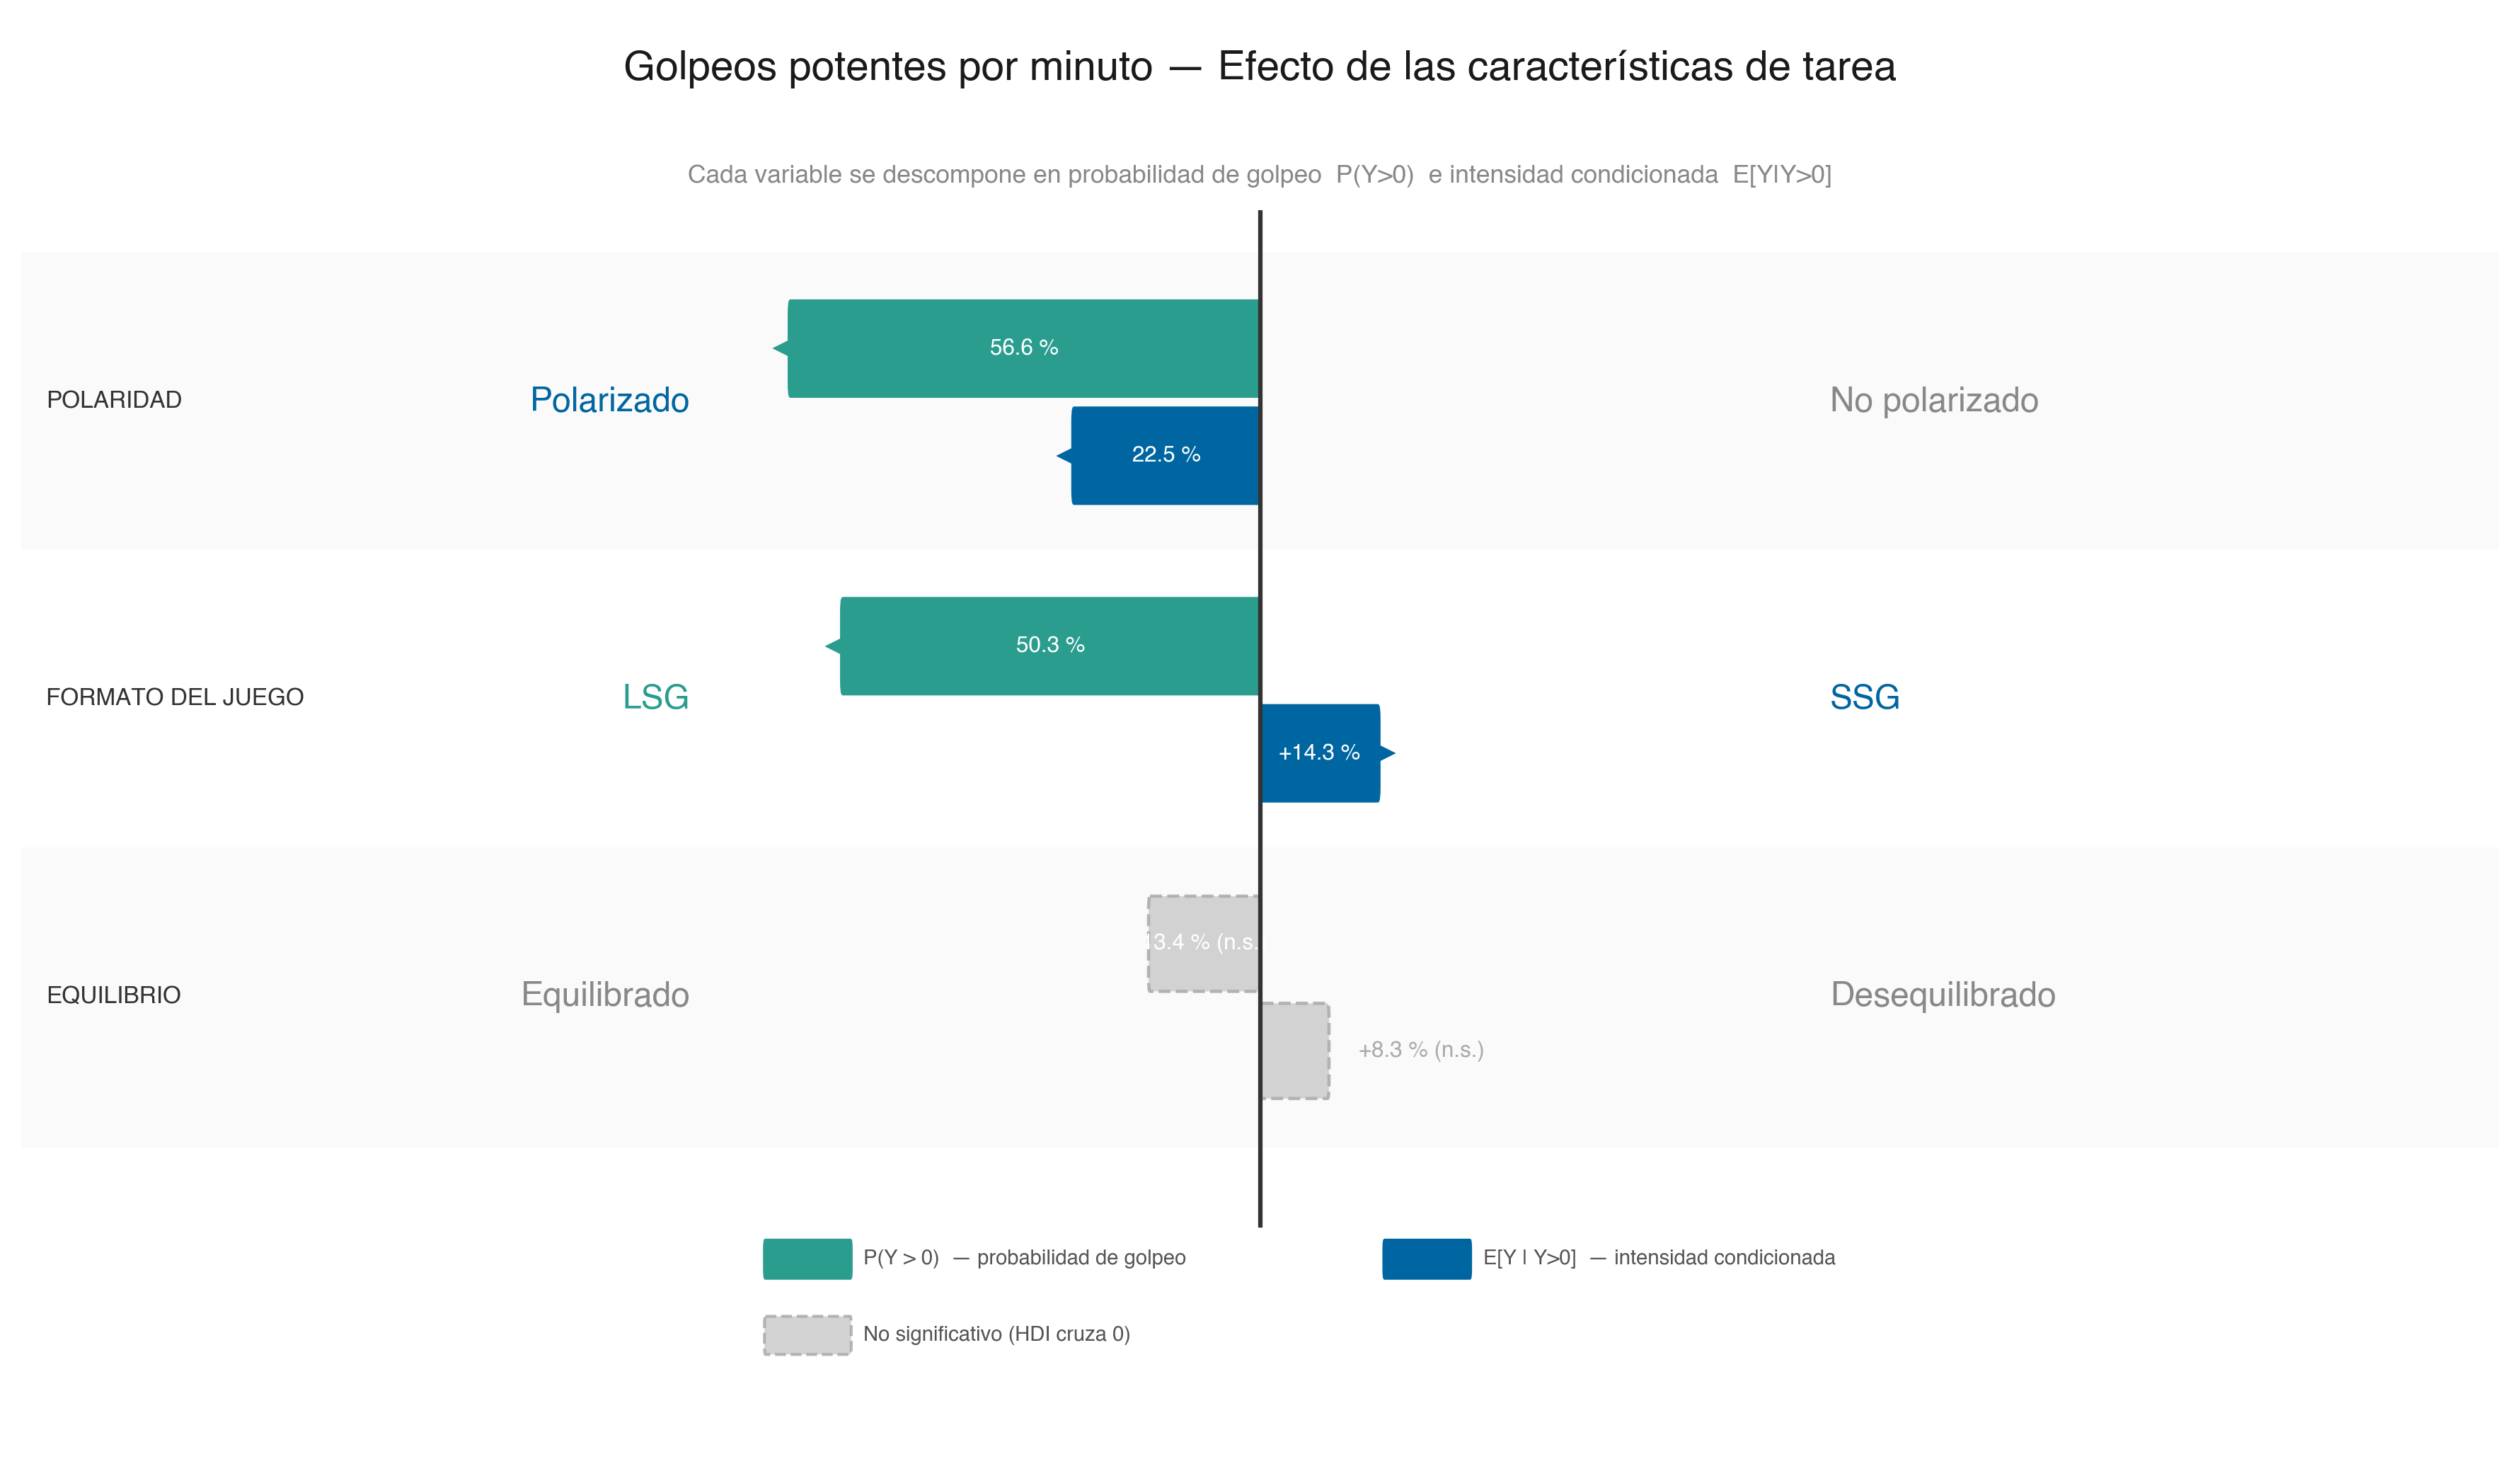

In [5]:
# ═══════════════════════════════════════════════════════════════════
# VARIANTE F — Barra divergente doble · Hurdle Gamma
#              (Golpeos >15 m/s / min)  — P(Y>0) + E[Y|Y>0]
# ═══════════════════════════════════════════════════════════════════
#
# NOTA: Este archivo glmm_golpeos_final.nc NO contiene los efectos fijos.
#       Para obtener los coeficientes, usar valores del análisis M1:
#       - Polaridad: psi β=-0.843 (OR=0.434), mu β=-0.256 (exp=0.775)
#       - Formato:   psi β=-0.704 (OR=0.497), mu β=+0.133 (exp=1.143)  
#       - Equilibrio: psi β=-0.151 (OR=0.866, n.s.), mu β=+0.079 (exp=1.083, n.s.)
#
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Colores ──────────────────────────────────────────────────────
BLUE_MU  = "#0066A1"     # componente mu  (intensidad)
TEAL_PSI = "#2A9D8F"     # componente psi (probabilidad)
GREY     = "#AAAAAA"
NS_BAR   = "#CCCCCC"
FONT     = ["Helvetica", "Arial", "DejaVu Sans"]

# ── Datos extraídos del modelo M1 (02_glmm_golpeos, celda 23) ───
# Ya exponenciados y con el signo correcto según flip_vars
rows_gol = [
    {
        "var": "Polaridad",
        "ref": "Polarizado",
        "alt": "No polarizado",
        # mu: E[Y|Y>0]
        "pct_mu": -22.5,  # exp(β)-1 = 0.775-1 = -0.225 = -22.5%
        "abs_mu": 22.5,
        "dir_mu": "left",  # negativo → gana ref (Polarizado)
        "sig_mu": True,
        # psi: P(Y>0)
        "pct_psi": -56.6,  # OR-1 = 0.434-1 = -0.566 = -56.6%
        "abs_psi": 56.6,
        "dir_psi": "left",  # negativo → gana ref (Polarizado)
        "sig_psi": True,
        "max_abs": 56.6,
    },
    {
        "var": "Formato del Juego",
        "ref": "LSG",
        "alt": "SSG",
        # mu
        "pct_mu": +14.3,  # exp(β)-1 = 1.143-1 = +0.143 = +14.3%
        "abs_mu": 14.3,
        "dir_mu": "right",  # positivo → gana alt (SSG)
        "sig_mu": True,
        # psi
        "pct_psi": -50.3,  # OR-1 = 0.497-1 = -0.503 = -50.3%
        "abs_psi": 50.3,
        "dir_psi": "left",  # negativo → gana ref (LSG)
        "sig_psi": True,
        "max_abs": 50.3,
    },
    {
        "var": "Equilibrio",
        "ref": "Equilibrado",
        "alt": "Desequilibrado",
        # mu
        "pct_mu": +8.3,  # exp(β)-1 = 1.083-1 = +0.083 = +8.3%
        "abs_mu": 8.3,
        "dir_mu": "right",
        "sig_mu": False,  # n.s.
        # psi
        "pct_psi": -13.4,  # OR-1 = 0.866-1 = -0.134 = -13.4%
        "abs_psi": 13.4,
        "dir_psi": "left",
        "sig_psi": False,  # n.s.
        "max_abs": 13.4,
    },
]

rows_gol.sort(key=lambda r: r["max_abs"], reverse=True)
n_gol = len(rows_gol)

print("Golpeos >15 m/s / min — Hurdle Gamma (M1)")
print(f"{'Variable':12s}  {'Componente':12s}  {'%cambio':>8s}  Sig")
print("─" * 50)
for r in rows_gol:
    for comp, lbl in [("psi", "P(Y>0)"), ("mu", "E[Y|Y>0]")]:
        pct = r[f"pct_{comp}"]
        sig = r[f"sig_{comp}"]
        sign = "+" if pct >= 0 else ""
        tag  = "✓" if sig else "✗"
        print(f"  {r['var']:12s}  {lbl:12s}  {sign}{pct:>6.1f} %  {tag}")
    print()

# ══════════════════════════════════════════════════════════════════
#                         GRÁFICO
# ══════════════════════════════════════════════════════════════════

LEFT_END    = 28
CENTER      = 50
RIGHT_START = 72
max_abs_g   = max(
    max(r["abs_mu"], r["abs_psi"]) for r in rows_gol
)
bar_reach   = 19

# Dos sub-barras por fila: psi arriba, mu abajo
sub_h    = 0.40            # altura de cada sub-barra
sub_gap  = 0.05            # separación entre las dos
row_sp   = 1.25            # separación entre centros de fila

fig_g, ax_g = plt.subplots(figsize=(12, 7), dpi=300)
ax_g.set_xlim(0, 100)
ax_g.set_ylim(-1.6, n_gol * row_sp + 0.6)
ax_g.invert_yaxis()
ax_g.set_aspect("auto")

for sp in ax_g.spines.values():
    sp.set_visible(False)
ax_g.set_xticks([])
ax_g.set_yticks([])

# Fondos alternos
for i in range(n_gol):
    yc = i * row_sp
    bg = "#FAFAFA" if i % 2 == 0 else "#FFFFFF"
    ax_g.axhspan(yc - 0.5 * row_sp, yc + 0.5 * row_sp, color=bg, zorder=0)

# Línea central
ax_g.axvline(CENTER, color="#333333", linewidth=1.5, zorder=6,
             ymin=0.15, ymax=0.865)

# ── Dibujar filas ────────────────────────────────────────────────
for i, r in enumerate(rows_gol):
    yc = i * row_sp   # centro de la fila

    for j, (comp, comp_color, comp_label) in enumerate([
        ("psi", TEAL_PSI, "P(Y>0)"),
        ("mu",  BLUE_MU,  "E[Y|Y>0]"),
    ]):
        # Posición vertical de la sub-barra (centrado en yc)
        y_bar = yc - (sub_h + sub_gap) / 2 + j * (sub_h + sub_gap)

        pct_abs = r[f"abs_{comp}"]
        direction = r[f"dir_{comp}"]
        sig = r[f"sig_{comp}"]

        bar_len = (pct_abs / max_abs_g) * bar_reach
        if bar_len < 0.3:
            bar_len = 0.3  # mínimo visible

        if sig:
            fc, ec, ls = comp_color, comp_color, "-"
            alpha_bar = 1.0
        else:
            fc, ec, ls = NS_BAR, GREY, "--"
            alpha_bar = 0.85

        # Posición x
        x0 = CENTER if direction == "right" else CENTER - bar_len

        fancy = FancyBboxPatch(
            (x0, y_bar - sub_h / 2), bar_len, sub_h,
            boxstyle="round,pad=0,rounding_size=0.06",
            facecolor=fc, edgecolor=ec,
            linewidth=1.1, linestyle=ls, alpha=alpha_bar, zorder=3)
        ax_g.add_patch(fancy)

        # Chevron
        if sig:
            mk = ">" if direction == "right" else "<"
            mx = (CENTER + bar_len + 0.3) if direction == "right" else (CENTER - bar_len - 0.3)
            ax_g.plot(mx, y_bar, marker=mk, markersize=4.5,
                      color=comp_color, zorder=4, clip_on=False)

        # Porcentaje
        pct_val = r[f"pct_{comp}"]
        sign_str = "+" if pct_val >= 0 else ""
        pct_txt = f"{sign_str}{pct_abs:.1f} %"
        if not sig:
            pct_txt += " (n.s.)"

        if bar_len > 3.5:
            ax_g.text(x0 + bar_len / 2, y_bar, pct_txt,
                      ha="center", va="center", fontsize=7.5,
                      fontweight="bold", color="white", zorder=5, fontfamily=FONT)
        else:
            if direction == "right":
                ax_g.text(CENTER + bar_len + 1.2, y_bar, pct_txt,
                          ha="left", va="center", fontsize=7.5,
                          fontweight="bold", color=ec, zorder=5, fontfamily=FONT)
            else:
                ax_g.text(CENTER - bar_len - 1.2, y_bar, pct_txt,
                          ha="right", va="center", fontsize=7.5,
                          fontweight="bold", color=ec, zorder=5, fontfamily=FONT)

    # ── Etiquetas izquierda y derecha ────────────────────────
    # Color según la barra significativa que apunta a ese lado
    left_col, left_wt = "#888888", "normal"
    right_col, right_wt = "#888888", "normal"
    for comp, comp_c in [("psi", TEAL_PSI), ("mu", BLUE_MU)]:
        if r[f"sig_{comp}"]:
            if r[f"dir_{comp}"] == "left":
                left_col, left_wt = comp_c, "bold"
            else:
                right_col, right_wt = comp_c, "bold"

    ax_g.text(LEFT_END - 1, yc, r["ref"],
              ha="right", va="center", fontsize=11.5,
              color=left_col, fontweight=left_wt, fontfamily=FONT)
    ax_g.text(RIGHT_START + 1, yc, r["alt"],
              ha="left", va="center", fontsize=11.5,
              color=right_col, fontweight=right_wt, fontfamily=FONT)

    # Nombre variable (ligeramente arriba del par de barras)
    ax_g.text(1, yc, r["var"].upper(),
              ha="left", va="center", fontsize=8,
              color="#333333", fontweight="medium", fontfamily=FONT)

# ── Leyenda inferior ─────────────────────────────────────────────
leg_y = n_gol * row_sp - 0.15

# P(Y>0)
p1 = FancyBboxPatch(
    (CENTER - 20, leg_y - 0.08), 3.5, 0.16,
    boxstyle="round,pad=0,rounding_size=0.04",
    facecolor=TEAL_PSI, edgecolor=TEAL_PSI, linewidth=1, zorder=3)
ax_g.add_patch(p1)
ax_g.text(CENTER - 16, leg_y, "P(Y > 0)  — probabilidad de golpeo",
          ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

# E[Y|Y>0]
p2 = FancyBboxPatch(
    (CENTER + 5, leg_y - 0.08), 3.5, 0.16,
    boxstyle="round,pad=0,rounding_size=0.04",
    facecolor=BLUE_MU, edgecolor=BLUE_MU, linewidth=1, zorder=3)
ax_g.add_patch(p2)
ax_g.text(CENTER + 9, leg_y, "E[Y | Y>0]  — intensidad condicionada",
          ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

# n.s.
p3 = FancyBboxPatch(
    (CENTER - 20, leg_y + 0.32 - 0.08), 3.5, 0.16,
    boxstyle="round,pad=0,rounding_size=0.04",
    facecolor=NS_BAR, edgecolor=GREY, linewidth=1, linestyle="--",
    alpha=0.85, zorder=3)
ax_g.add_patch(p3)
ax_g.text(CENTER - 16, leg_y + 0.32, "No significativo (HDI cruza 0)",
          ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

# ── Título y subtítulo ───────────────────────────────────────────
ax_g.text(CENTER, -1.4,
          "Golpeos potentes por minuto — Efecto de las características de tarea",
          ha="center", va="center", fontsize=14, fontweight="bold",

          color="#1a1a1a", fontfamily=FONT, zorder=10)
ax_g.text(CENTER, -0.95,
          "Cada variable se descompone en probabilidad de golpeo  P(Y>0)  "
          "e intensidad condicionada  E[Y|Y>0]",
          ha="center", va="center", fontsize=8.5, color="#888888",
          fontstyle="italic", fontfamily=FONT, zorder=10)

fig_g.patch.set_facecolor("white")
fig_g.tight_layout()
plt.show()

HID / min — Hurdle Gamma (M2)
Variable      Componente     %cambio  Sig
──────────────────────────────────────────────────
  Formato del Juego  P(Y>0)         -83.2 %  ✓
  Formato del Juego  E[Y|Y>0]       -76.5 %  ✓

  Equilibrio    P(Y>0)         -56.8 %  ✓
  Equilibrio    E[Y|Y>0]      +  12.5 %  ✗

  Polaridad     P(Y>0)         -53.4 %  ✓
  Polaridad     E[Y|Y>0]       -41.4 %  ✓



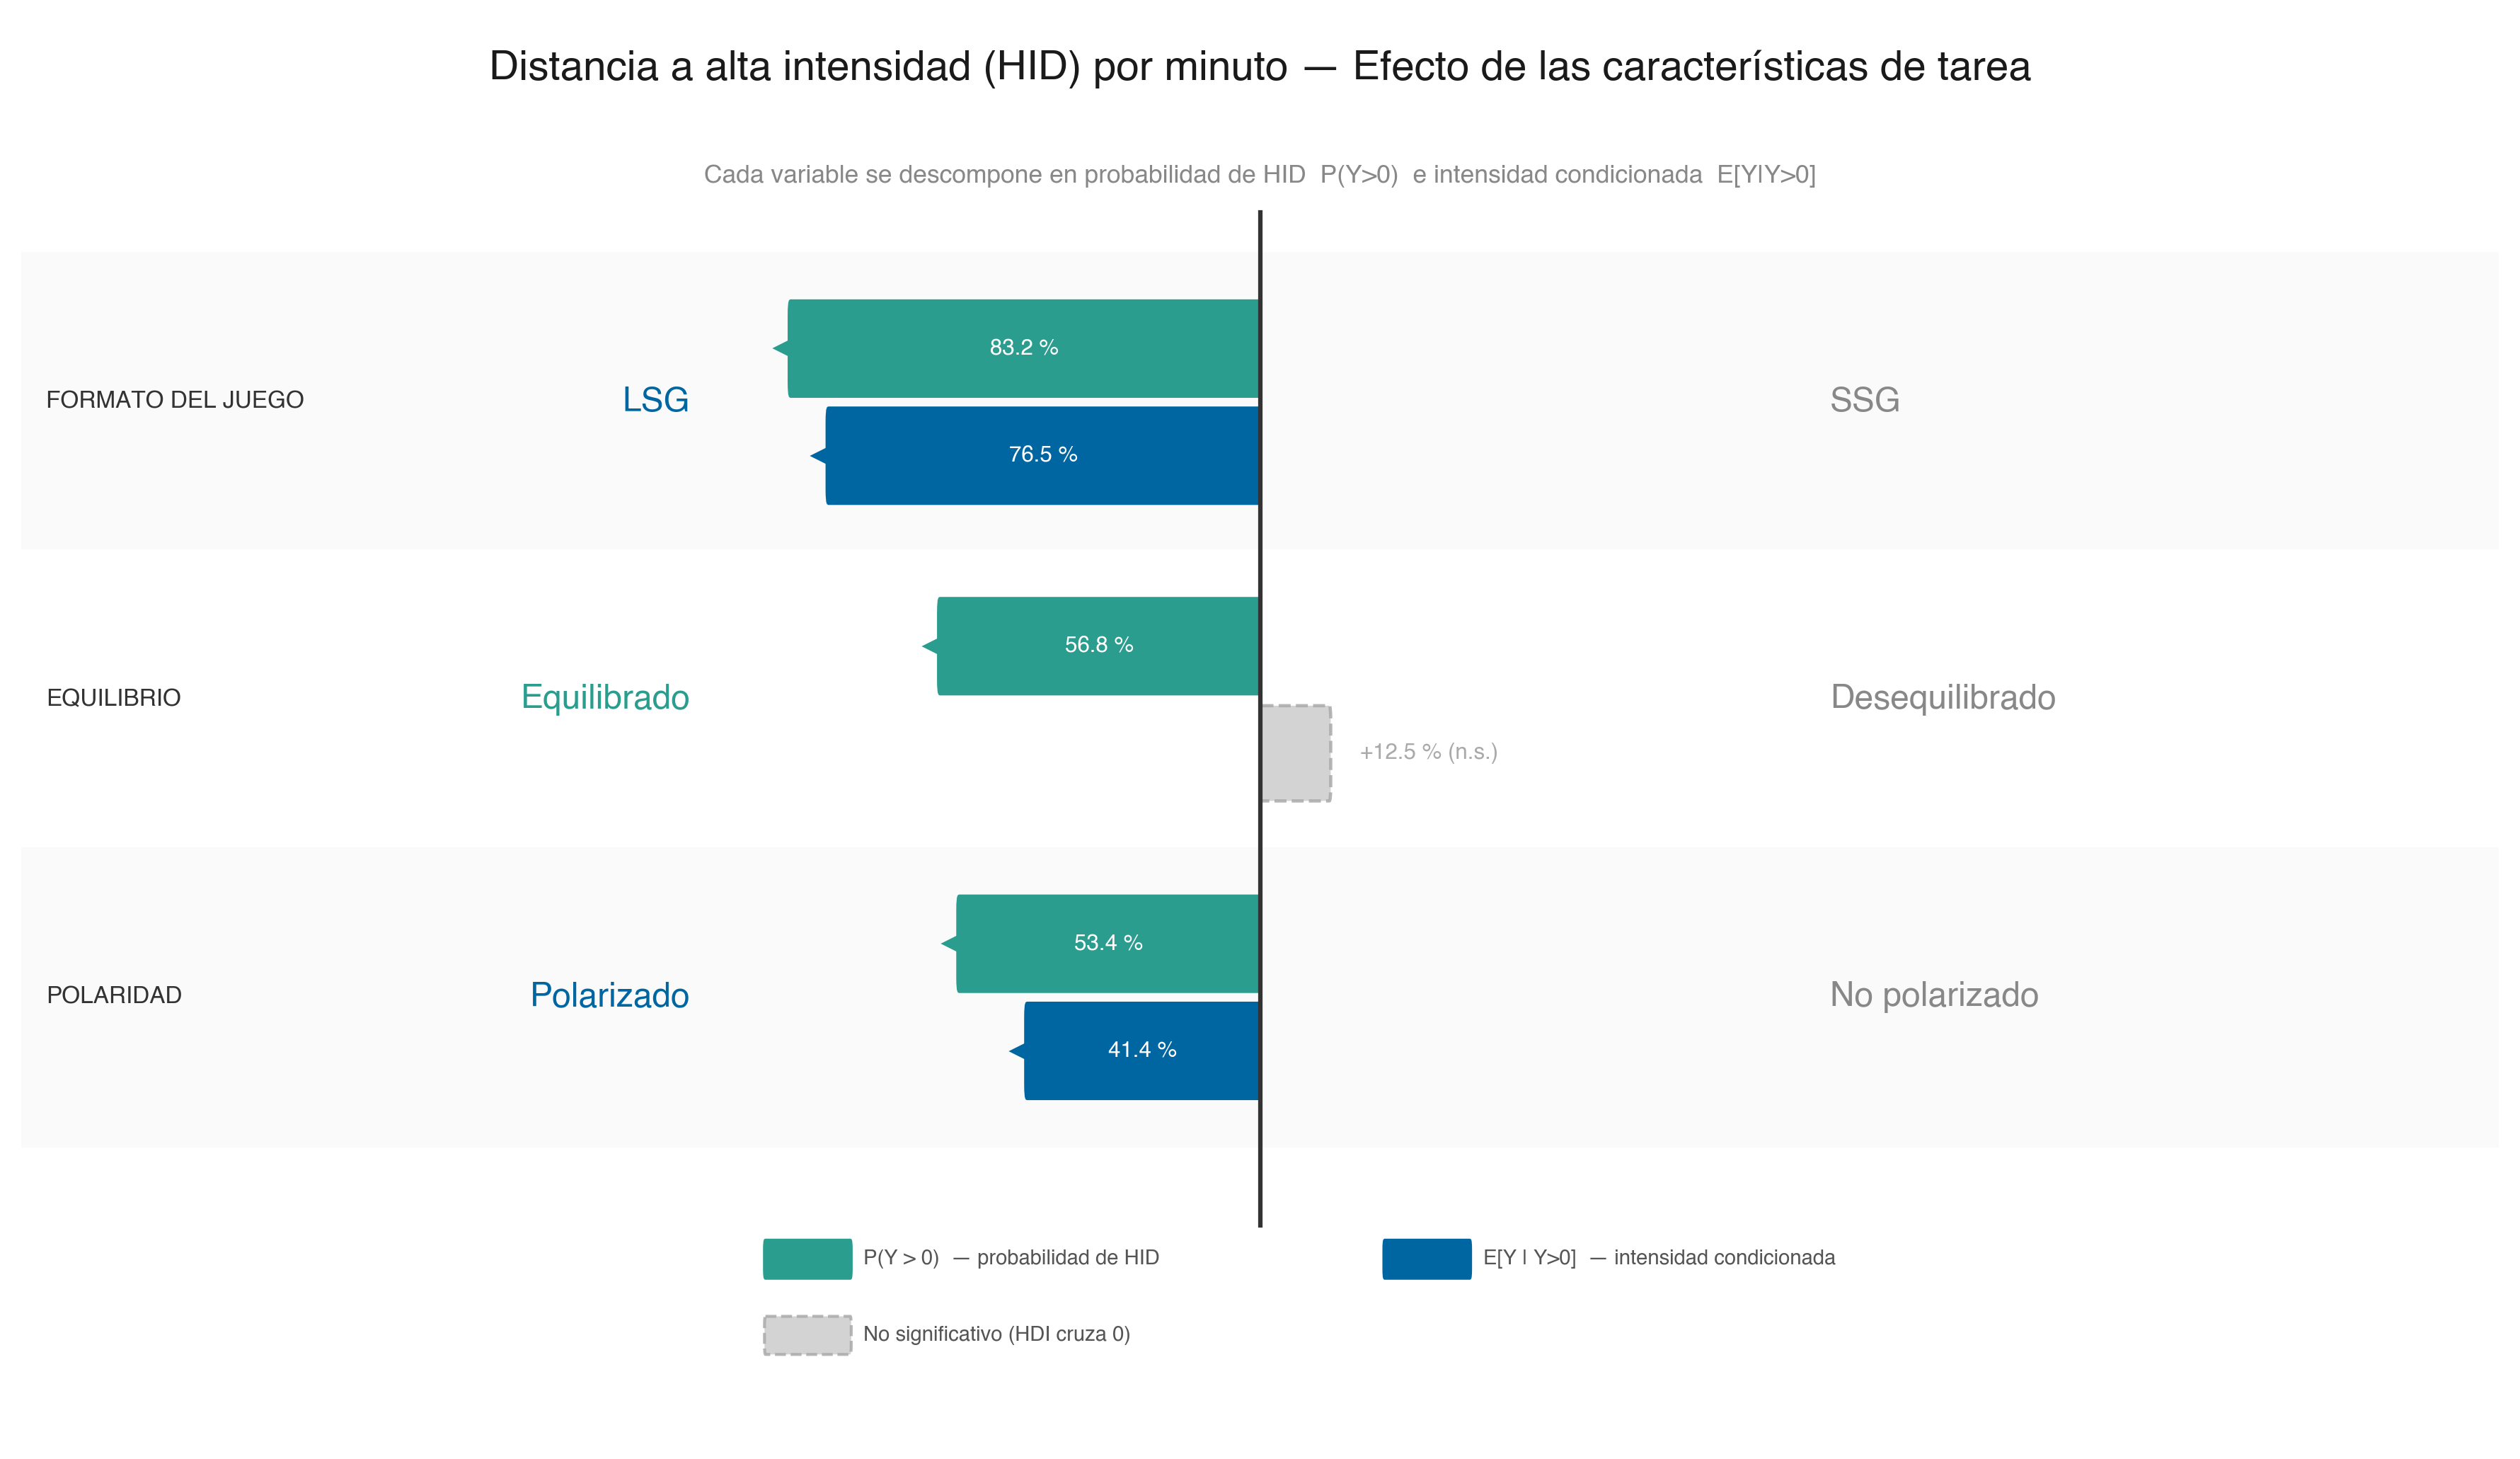

In [6]:
# ═══════════════════════════════════════════════════════════════════
# VARIANTE F — Barra divergente doble · Hurdle Gamma
#              (HID / min)  — P(Y>0) + E[Y|Y>0]
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import arviz as az

# ── Colores ──────────────────────────────────────────────────────
BLUE_MU  = "#0066A1"     # componente mu  (intensidad)
TEAL_PSI = "#2A9D8F"     # componente psi (probabilidad)
GREY     = "#AAAAAA"
NS_BAR   = "#CCCCCC"
FONT     = ["Helvetica", "Arial", "DejaVu Sans"]

# ── Cargar modelo (idata_HID_final.nc tiene ambos componentes) ──
idata_hid = az.from_netcdf("../Datos/idata_HID_final.nc")
post_hid  = idata_hid.posterior

# ── Mapa de variables ────────────────────────────────────────────
var_map_hid = [
    {"var": "Polaridad",  "param": "Polaridad",  "ref": "Polarizado",   "alt": "No polarizado",  "flip": True},
    {"var": "Formato del Juego", "param": "Formato_del_Juego", "ref": "LSG", "alt": "SSG", "flip": False},
    {"var": "Equilibrio", "param": "Equilibrio",  "ref": "Equilibrado",  "alt": "Desequilibrado", "flip": True},
]

# ── Extraer ambos componentes ────────────────────────────────────
rows_hid = []
for v in var_map_hid:
    # --- mu: E[Y | Y > 0]  (Gamma, log-link) ---
    # Los parámetros tienen dim extra de tamaño 1 → squeeze
    beta_mu = post_hid[v["param"]].values.squeeze().flatten()
    if v["flip"]:
        beta_mu = -beta_mu
    pct_mu     = float(np.median((np.exp(beta_mu) - 1) * 100))
    hdi_mu     = az.hdi(beta_mu, prob=0.95)
    sig_mu     = not (hdi_mu[0] <= 0 <= hdi_mu[1])

    # --- psi: P(Y > 0)  (Bernoulli, logit-link) ---
    beta_psi = post_hid[f"psi_{v['param']}"].values.squeeze().flatten()
    if v["flip"]:
        beta_psi = -beta_psi
    pct_psi    = float(np.median((np.exp(beta_psi) - 1) * 100))
    hdi_psi    = az.hdi(beta_psi, prob=0.95)
    sig_psi    = not (hdi_psi[0] <= 0 <= hdi_psi[1])

    rows_hid.append({
        "var":  v["var"],
        "ref":  v["ref"],
        "alt":  v["alt"],
        # mu
        "pct_mu":  round(pct_mu, 1),
        "abs_mu":  round(abs(pct_mu), 1),
        "dir_mu":  "right" if pct_mu >= 0 else "left",
        "sig_mu":  sig_mu,
        # psi
        "pct_psi": round(pct_psi, 1),
        "abs_psi": round(abs(pct_psi), 1),
        "dir_psi": "right" if pct_psi >= 0 else "left",
        "sig_psi": sig_psi,
        # para ordenar
        "max_abs": max(abs(pct_mu), abs(pct_psi)),
    })

rows_hid.sort(key=lambda r: r["max_abs"], reverse=True)
n_hid = len(rows_hid)

print("HID / min — Hurdle Gamma (M2)")
print(f"{'Variable':12s}  {'Componente':12s}  {'%cambio':>8s}  Sig")
print("─" * 50)
for r in rows_hid:
    for comp, lbl in [("psi", "P(Y>0)"), ("mu", "E[Y|Y>0]")]:
        pct = r[f"pct_{comp}"]
        sig = r[f"sig_{comp}"]
        sign = "+" if pct >= 0 else ""
        tag  = "✓" if sig else "✗"
        print(f"  {r['var']:12s}  {lbl:12s}  {sign}{pct:>6.1f} %  {tag}")
    print()

# ══════════════════════════════════════════════════════════════════
#                         GRÁFICO
# ══════════════════════════════════════════════════════════════════

LEFT_END    = 28
CENTER      = 50
RIGHT_START = 72
max_abs_h   = max(
    max(r["abs_mu"], r["abs_psi"]) for r in rows_hid
)
bar_reach   = 19

# Dos sub-barras por fila: psi arriba, mu abajo
sub_h    = 0.40
sub_gap  = 0.05
row_sp   = 1.25

fig_h, ax_h = plt.subplots(figsize=(12, 7), dpi=300)
ax_h.set_xlim(0, 100)
ax_h.set_ylim(-1.6, n_hid * row_sp + 0.6)
ax_h.invert_yaxis()
ax_h.set_aspect("auto")

for sp in ax_h.spines.values():
    sp.set_visible(False)
ax_h.set_xticks([])
ax_h.set_yticks([])

# Fondos alternos
for i in range(n_hid):
    yc = i * row_sp
    bg = "#FAFAFA" if i % 2 == 0 else "#FFFFFF"
    ax_h.axhspan(yc - 0.5 * row_sp, yc + 0.5 * row_sp, color=bg, zorder=0)

# Línea central
ax_h.axvline(CENTER, color="#333333", linewidth=1.5, zorder=6,
             ymin=0.15, ymax=0.865)

# ── Dibujar filas ────────────────────────────────────────────────
for i, r in enumerate(rows_hid):
    yc = i * row_sp

    for j, (comp, comp_color, comp_label) in enumerate([
        ("psi", TEAL_PSI, "P(Y>0)"),
        ("mu",  BLUE_MU,  "E[Y|Y>0]"),
    ]):
        y_bar = yc - (sub_h + sub_gap) / 2 + j * (sub_h + sub_gap)

        pct_abs = r[f"abs_{comp}"]
        direction = r[f"dir_{comp}"]
        sig = r[f"sig_{comp}"]

        bar_len = (pct_abs / max_abs_h) * bar_reach
        if bar_len < 0.3:
            bar_len = 0.3

        if sig:
            fc, ec, ls = comp_color, comp_color, "-"
            alpha_bar = 1.0
        else:
            fc, ec, ls = NS_BAR, GREY, "--"
            alpha_bar = 0.85

        x0 = CENTER if direction == "right" else CENTER - bar_len

        fancy = FancyBboxPatch(
            (x0, y_bar - sub_h / 2), bar_len, sub_h,
            boxstyle="round,pad=0,rounding_size=0.06",
            facecolor=fc, edgecolor=ec,
            linewidth=1.1, linestyle=ls, alpha=alpha_bar, zorder=3)
        ax_h.add_patch(fancy)

        # Chevron
        if sig:
            mk = ">" if direction == "right" else "<"
            mx = (CENTER + bar_len + 0.3) if direction == "right" else (CENTER - bar_len - 0.3)
            ax_h.plot(mx, y_bar, marker=mk, markersize=4.5,
                      color=comp_color, zorder=4, clip_on=False)

        # Porcentaje
        pct_val = r[f"pct_{comp}"]
        sign_str = "+" if pct_val >= 0 else ""
        pct_txt = f"{sign_str}{pct_abs:.1f} %"
        if not sig:
            pct_txt += " (n.s.)"

        if bar_len > 3.5:
            ax_h.text(x0 + bar_len / 2, y_bar, pct_txt,
                      ha="center", va="center", fontsize=7.5,
                      fontweight="bold", color="white", zorder=5, fontfamily=FONT)
        else:
            if direction == "right":
                ax_h.text(CENTER + bar_len + 1.2, y_bar, pct_txt,
                          ha="left", va="center", fontsize=7.5,
                          fontweight="bold", color=ec, zorder=5, fontfamily=FONT)
            else:
                ax_h.text(CENTER - bar_len - 1.2, y_bar, pct_txt,
                          ha="right", va="center", fontsize=7.5,
                          fontweight="bold", color=ec, zorder=5, fontfamily=FONT)

    # ── Etiquetas izquierda y derecha ────────────────────────
    left_col, left_wt = "#888888", "normal"
    right_col, right_wt = "#888888", "normal"
    for comp, comp_c in [("psi", TEAL_PSI), ("mu", BLUE_MU)]:
        if r[f"sig_{comp}"]:
            if r[f"dir_{comp}"] == "left":
                left_col, left_wt = comp_c, "bold"
            else:
                right_col, right_wt = comp_c, "bold"

    ax_h.text(LEFT_END - 1, yc, r["ref"],
              ha="right", va="center", fontsize=11.5,
              color=left_col, fontweight=left_wt, fontfamily=FONT)
    ax_h.text(RIGHT_START + 1, yc, r["alt"],
              ha="left", va="center", fontsize=11.5,
              color=right_col, fontweight=right_wt, fontfamily=FONT)

    # Nombre variable centrado en la fila
    ax_h.text(1, yc, r["var"].upper(),
              ha="left", va="center", fontsize=8,
              color="#333333", fontweight="medium", fontfamily=FONT)

# ── Leyenda inferior ─────────────────────────────────────────────
leg_y = n_hid * row_sp - 0.15

# P(Y>0)
p1 = FancyBboxPatch(
    (CENTER - 20, leg_y - 0.08), 3.5, 0.16,
    boxstyle="round,pad=0,rounding_size=0.04",
    facecolor=TEAL_PSI, edgecolor=TEAL_PSI, linewidth=1, zorder=3)
ax_h.add_patch(p1)
ax_h.text(CENTER - 16, leg_y, "P(Y > 0)  — probabilidad de HID",
          ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

# E[Y|Y>0]
p2 = FancyBboxPatch(
    (CENTER + 5, leg_y - 0.08), 3.5, 0.16,
    boxstyle="round,pad=0,rounding_size=0.04",
    facecolor=BLUE_MU, edgecolor=BLUE_MU, linewidth=1, zorder=3)
ax_h.add_patch(p2)
ax_h.text(CENTER + 9, leg_y, "E[Y | Y>0]  — intensidad condicionada",
          ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

# n.s.
p3 = FancyBboxPatch(
    (CENTER - 20, leg_y + 0.32 - 0.08), 3.5, 0.16,
    boxstyle="round,pad=0,rounding_size=0.04",
    facecolor=NS_BAR, edgecolor=GREY, linewidth=1, linestyle="--",
    alpha=0.85, zorder=3)
ax_h.add_patch(p3)
ax_h.text(CENTER - 16, leg_y + 0.32, "No significativo (HDI cruza 0)",
          ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

# ── Título y subtítulo ───────────────────────────────────────────
ax_h.text(CENTER, -1.4,
          "Distancia a alta intensidad (HID) por minuto — Efecto de las características de tarea",
          ha="center", va="center", fontsize=14, fontweight="bold",
          color="#1a1a1a", fontfamily=FONT, zorder=10)

ax_h.text(CENTER, -0.95,
          "Cada variable se descompone en probabilidad de HID  P(Y>0)  "
          "e intensidad condicionada  E[Y|Y>0]",
          ha="center", va="center", fontsize=8.5, color="#888888",
          fontstyle="italic", fontfamily=FONT, zorder=10)

fig_h.patch.set_facecolor("white")
fig_h.tight_layout()
plt.show()

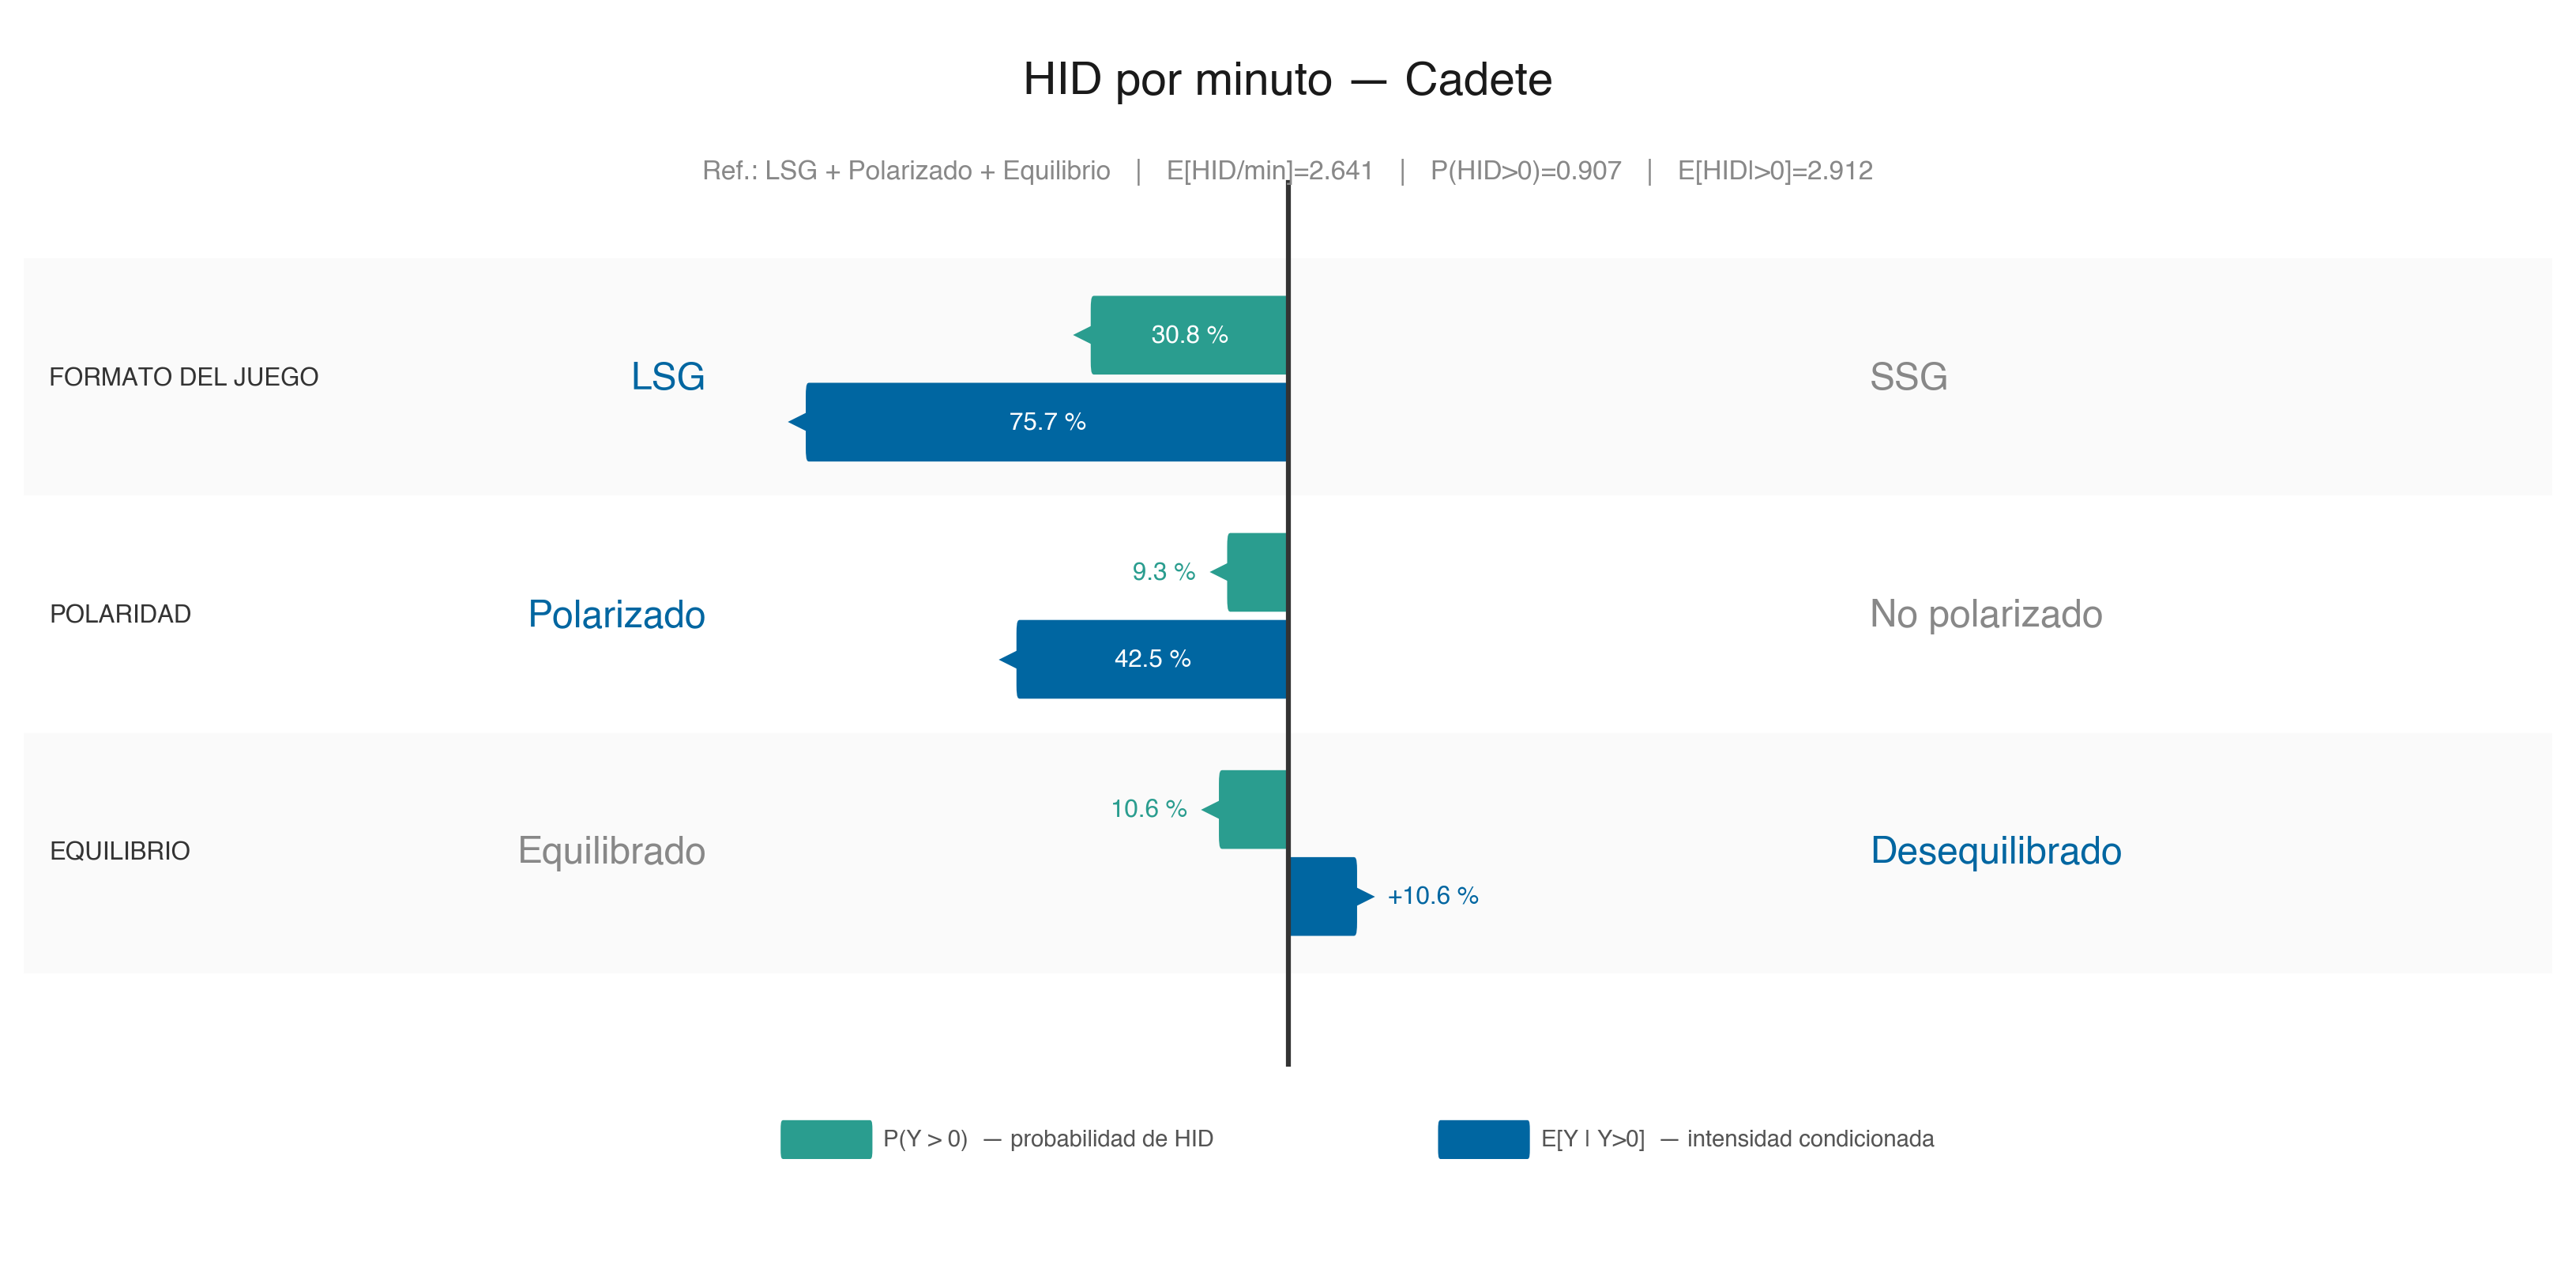

✓ Cadete guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Cadete.png


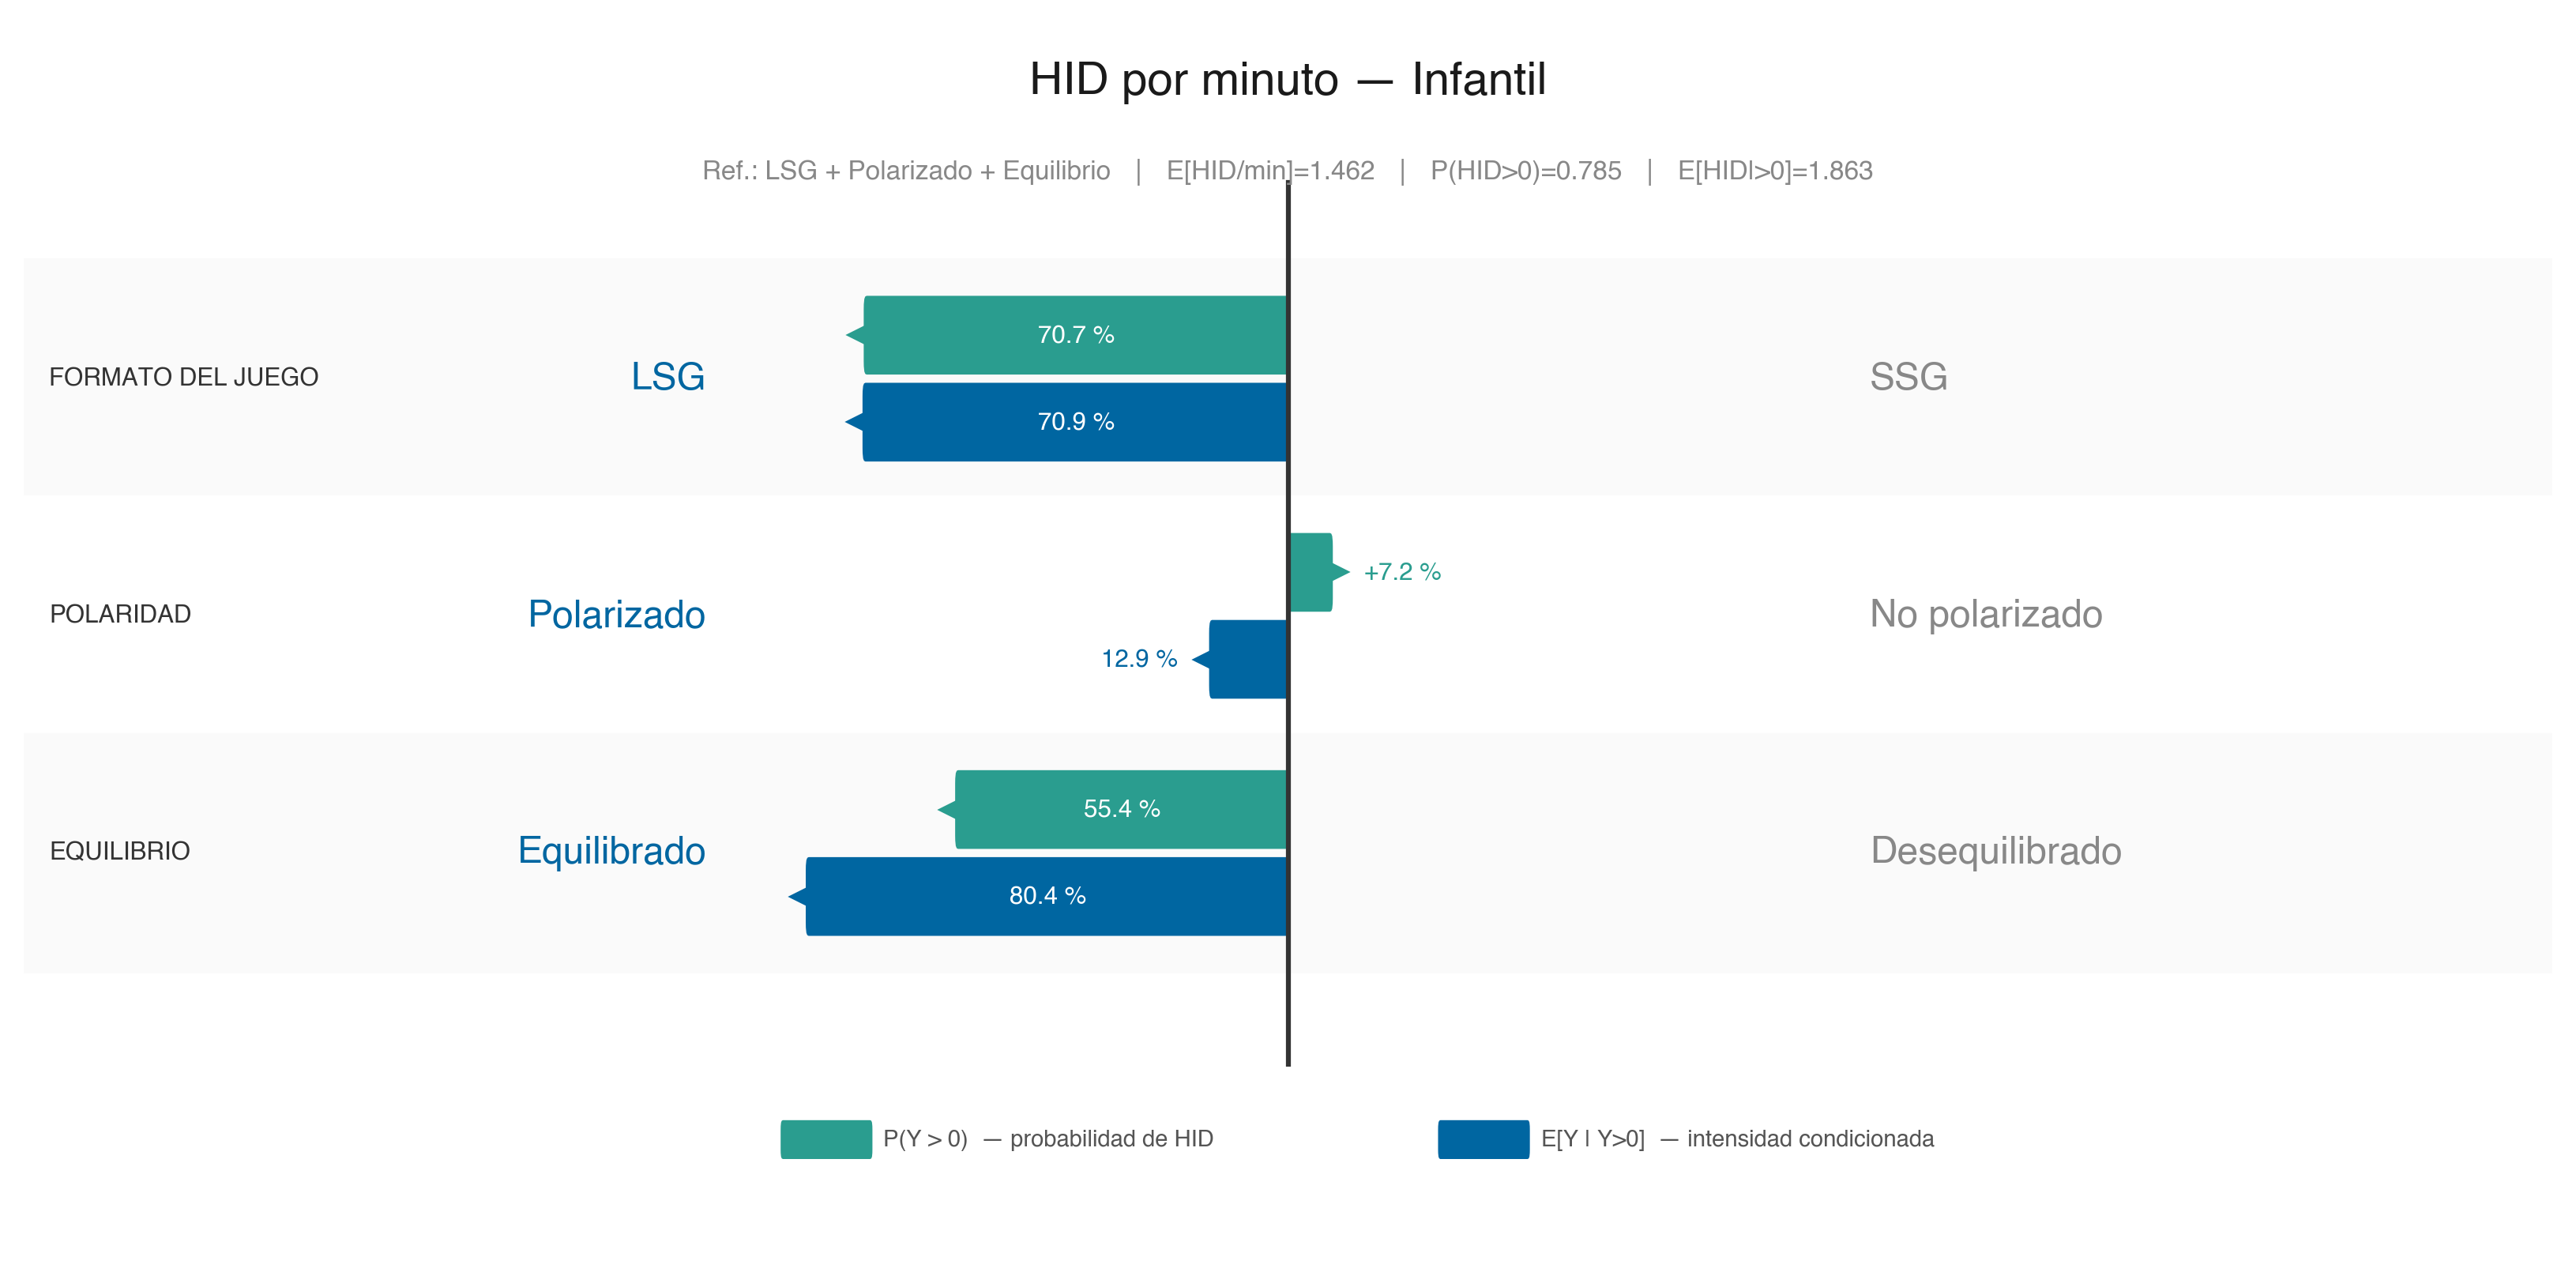

✓ Infantil guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Infantil.png


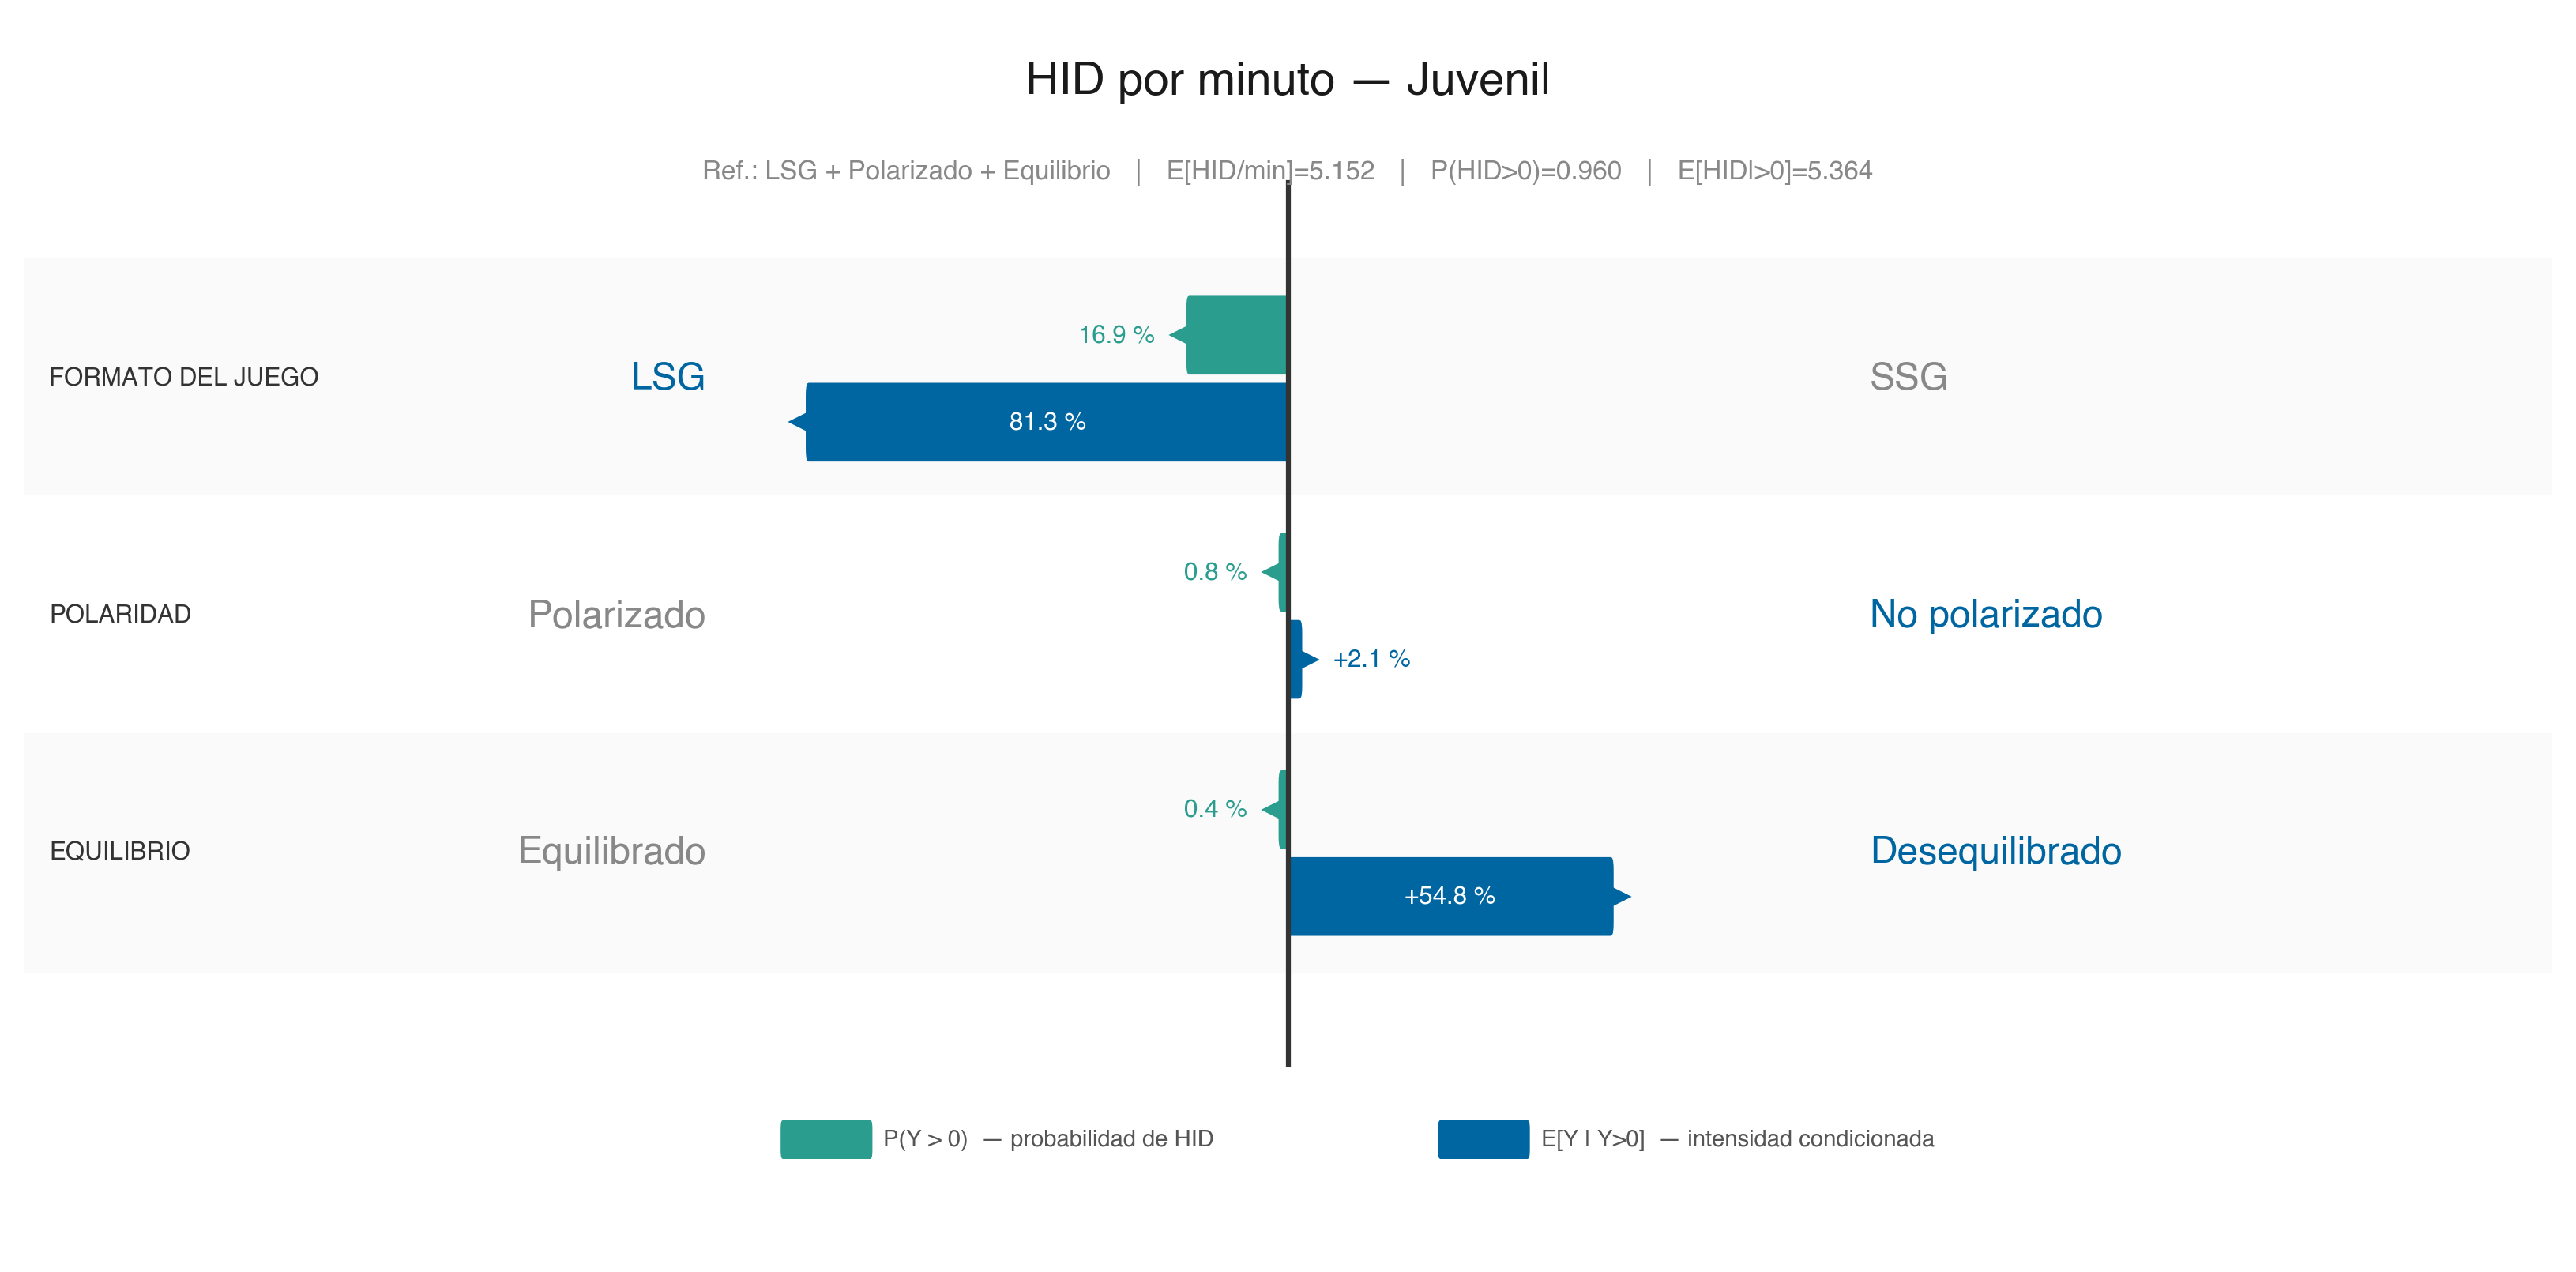

✓ Juvenil guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Juvenil.png


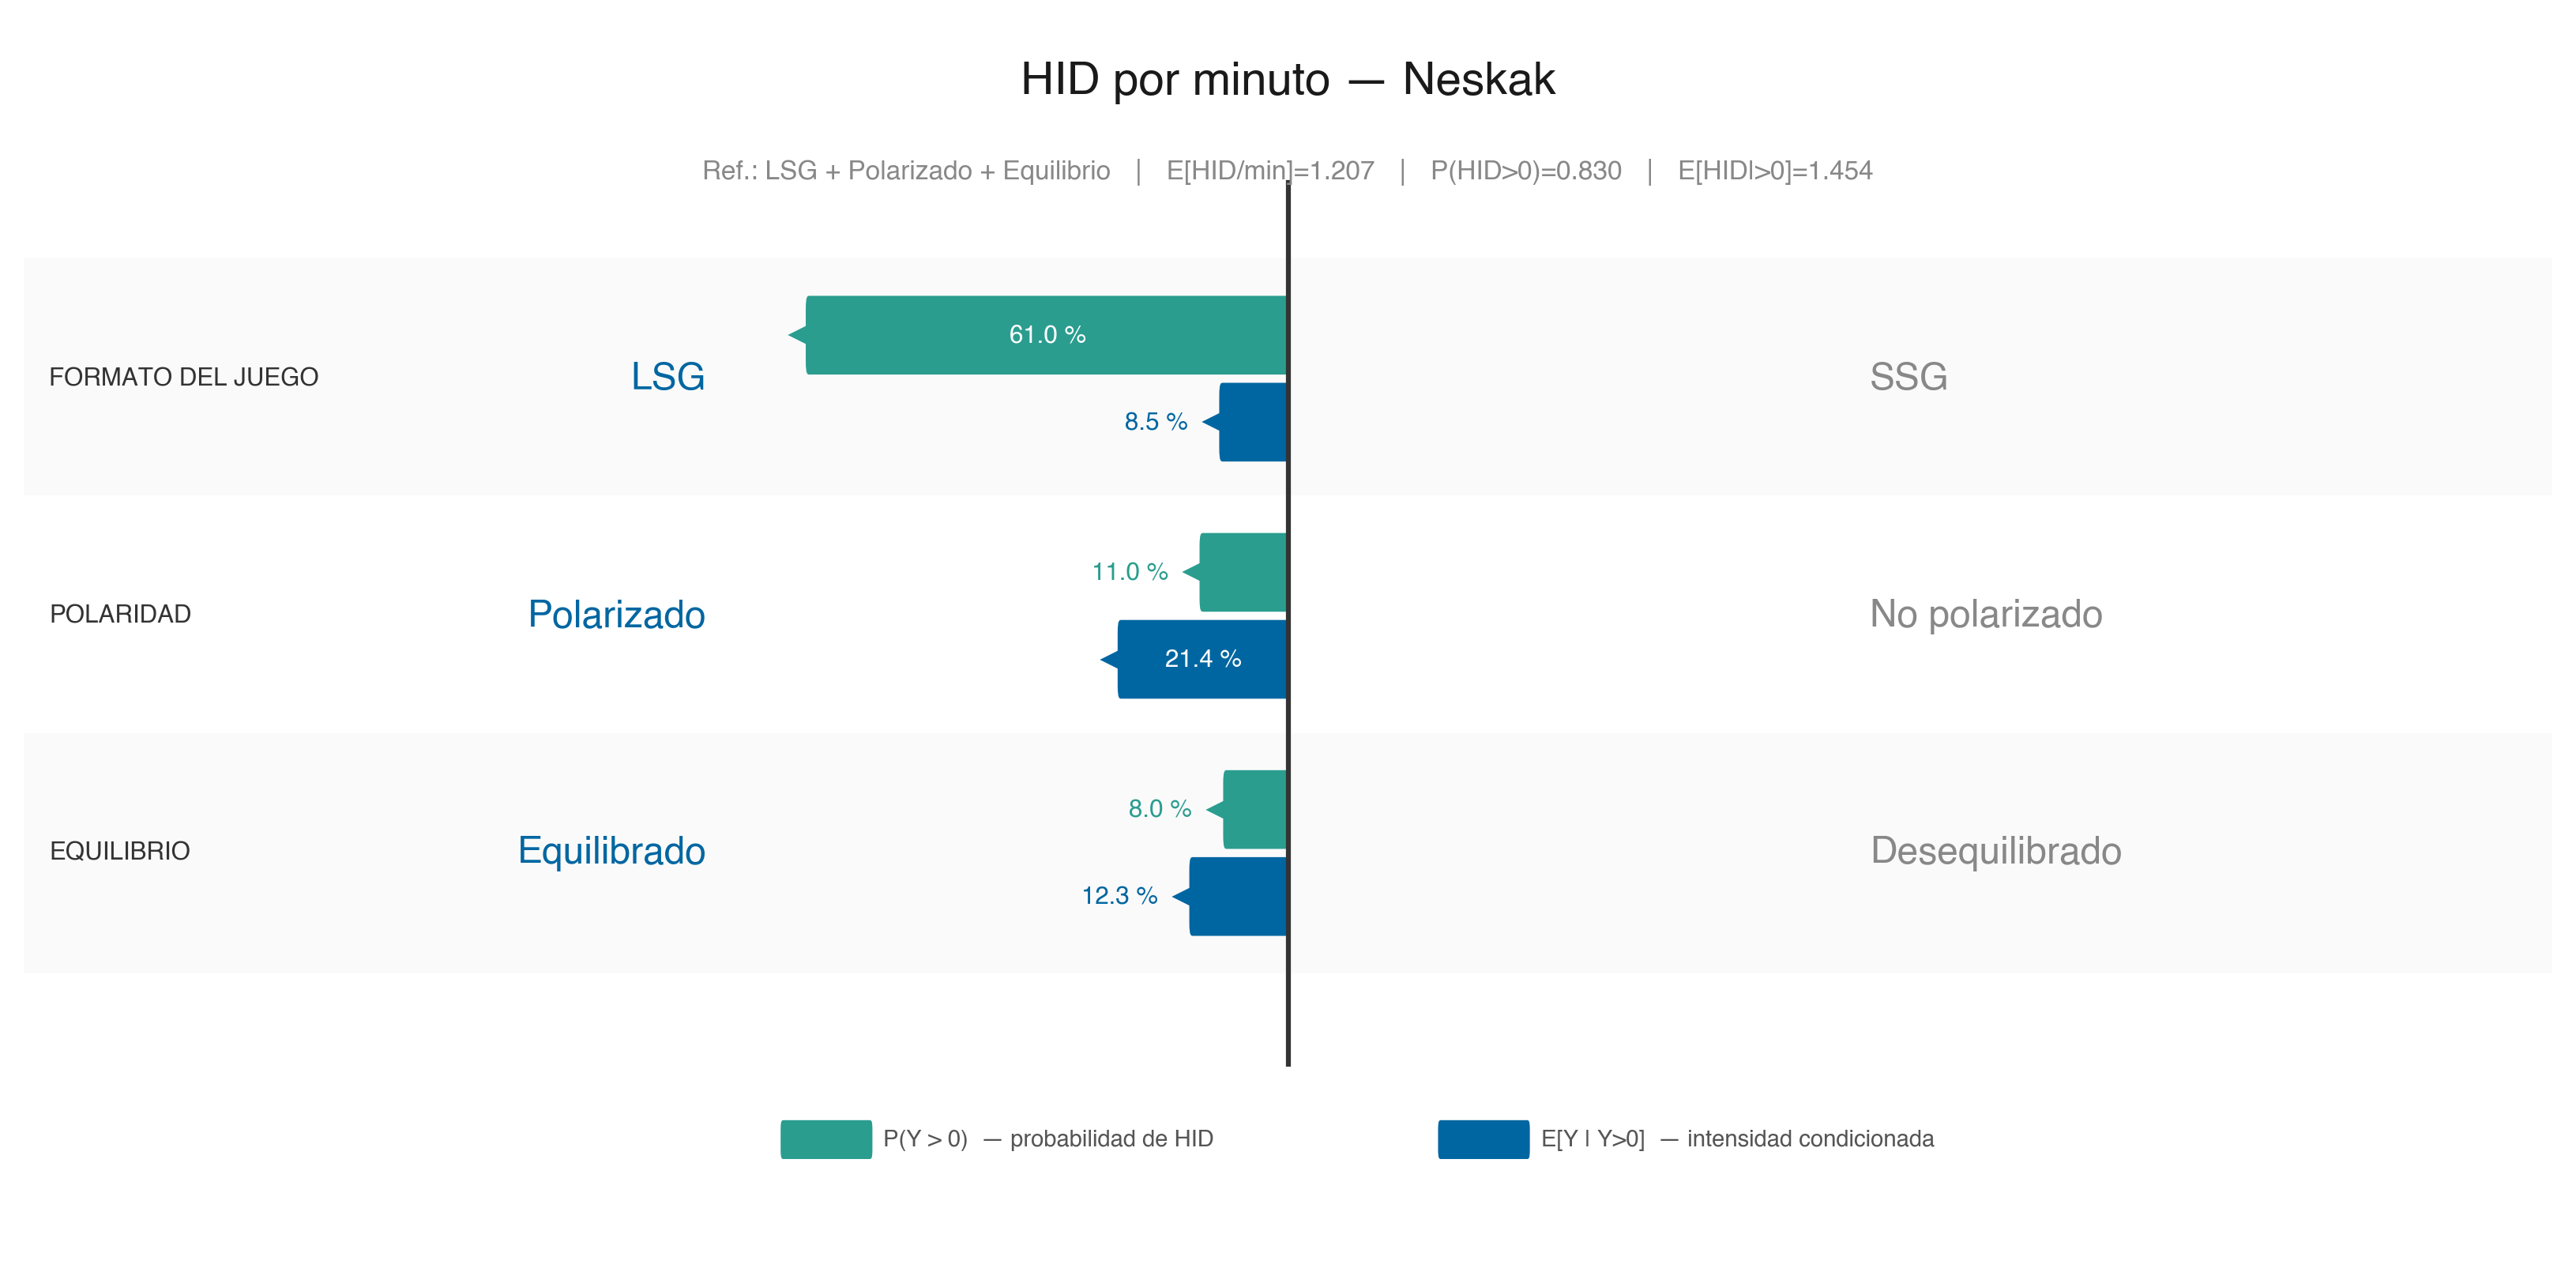

✓ Neskak guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Neskak.png


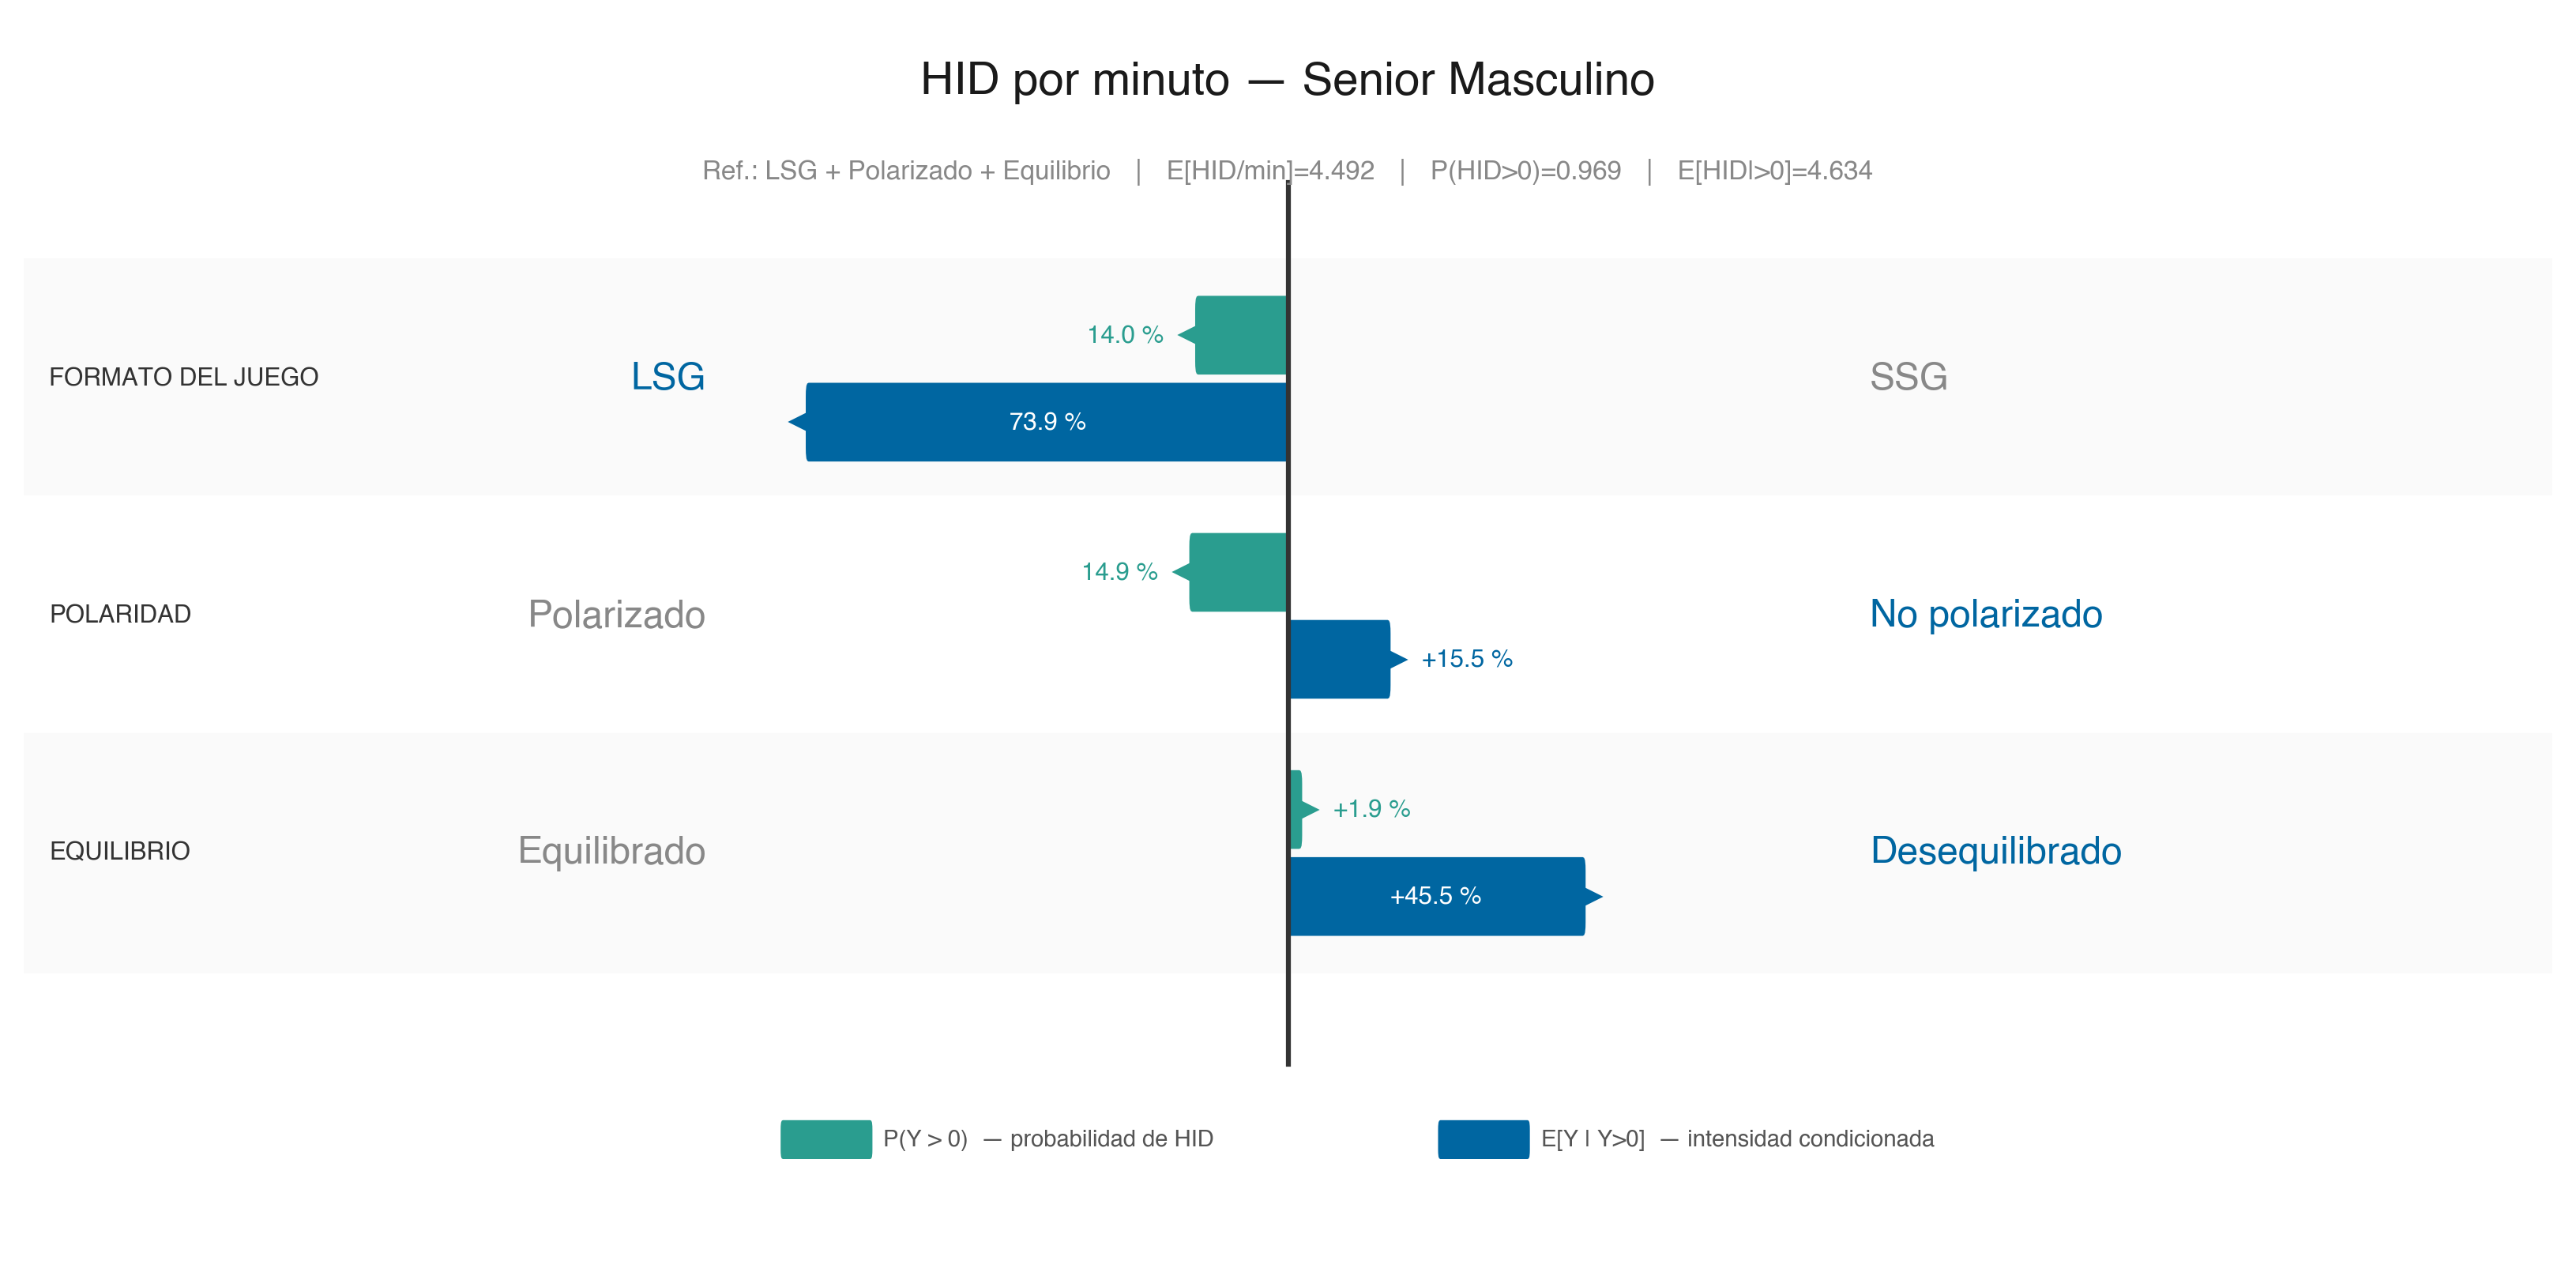

✓ Senior Masculino guardado en ../Graficos/grupoedad_HID/HID_grupoedad_Senior_Masculino.png

Todos los gráficos generados.


In [8]:
# ═══════════════════════════════════════════════════════════════════
# VARIANTE F — Barra divergente doble · Hurdle Gamma
#              (HID / min)  — UN GRÁFICO POR GRUPO DE EDAD
#              Datos extraídos de Tablas 1-3 del notebook 04_glmm_HID
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import os

# ── Colores ──────────────────────────────────────────────────────
BLUE_MU  = "#0066A1"
TEAL_PSI = "#2A9D8F"
GREY     = "#AAAAAA"
FONT     = ["Helvetica", "Arial", "DejaVu Sans"]

# ── Datos de las Tablas 1 (E[Y]), 2 (P(Y>0)=psi) y 3 (E[Y|Y>0]=mu) ──
# Referencia base: LSG + Polarizado + Equilibrio
# Δ = impacto al cambiar desde la referencia:
#   Formato:    LSG → SSG
#   Polaridad:  Polarizado → No_polarizado
#   Equilibrio: Equilibrio → Desequilibrio
grupos = {
    "Cadete": {
        "E_ref": 2.641, "P_ref": 0.907, "mu_ref": 2.912,
        "psi": {"Formato del Juego": -30.8, "Polaridad": -9.3,  "Equilibrio": -10.6},
        "mu":  {"Formato del Juego": -75.7, "Polaridad": -42.5, "Equilibrio": +10.6},
    },
    "Infantil": {
        "E_ref": 1.462, "P_ref": 0.785, "mu_ref": 1.863,
        "psi": {"Formato del Juego": -70.7, "Polaridad": +7.2,  "Equilibrio": -55.4},
        "mu":  {"Formato del Juego": -70.9, "Polaridad": -12.9, "Equilibrio": -80.4},
    },
    "Juvenil": {
        "E_ref": 5.152, "P_ref": 0.960, "mu_ref": 5.364,
        "psi": {"Formato del Juego": -16.9, "Polaridad": -0.8,  "Equilibrio": -0.4},
        "mu":  {"Formato del Juego": -81.3, "Polaridad": +2.1,  "Equilibrio": +54.8},
    },
    "Neskak": {
        "E_ref": 1.207, "P_ref": 0.830, "mu_ref": 1.454,
        "psi": {"Formato del Juego": -61.0, "Polaridad": -11.0, "Equilibrio": -8.0},
        "mu":  {"Formato del Juego":  -8.5, "Polaridad": -21.4, "Equilibrio": -12.3},
    },
    "Senior Masculino": {
        "E_ref": 4.492, "P_ref": 0.969, "mu_ref": 4.634,
        "psi": {"Formato del Juego": -14.0, "Polaridad": -14.9, "Equilibrio": +1.9},
        "mu":  {"Formato del Juego": -73.9, "Polaridad": +15.5, "Equilibrio": +45.5},
    },
}

# Etiquetas ref/alt por variable
var_labels = {
    "Formato del Juego": ("LSG", "SSG"),
    "Polaridad":         ("Polarizado", "No polarizado"),
    "Equilibrio":        ("Equilibrado", "Desequilibrado"),
}

# ── Directorio de salida ─────────────────────────────────────────
OUT_DIR = "../Graficos/grupoedad_HID"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Geometría (igual que la Variante F base) ─────────────────────
LEFT_END    = 28
CENTER      = 50
RIGHT_START = 72
bar_reach   = 19      # px normalizado máximo por componente
sub_h       = 0.38
sub_gap     = 0.06
row_sp      = 1.20

# ── Bucle principal: un gráfico por grupo ────────────────────────
for grupo, d in grupos.items():

    # Construir filas en orden fijo: Formato, Polaridad, Equilibrio
    rows = []
    for var in ["Formato del Juego", "Polaridad", "Equilibrio"]:
        pct_psi = d["psi"][var]
        pct_mu  = d["mu"][var]
        rows.append({
            "var":     var,
            "ref":     var_labels[var][0],
            "alt":     var_labels[var][1],
            "pct_psi": pct_psi, "abs_psi": abs(pct_psi),
            "dir_psi": "right" if pct_psi >= 0 else "left",
            "pct_mu":  pct_mu,  "abs_mu":  abs(pct_mu),
            "dir_mu":  "right" if pct_mu  >= 0 else "left",
            "max_abs": max(abs(pct_psi), abs(pct_mu)),
        })
    # Orden fijo: no se ordena por max_abs
    n = len(rows)

    max_abs_all = max(r["max_abs"] for r in rows)

    # ── Figura ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)
    ax.set_xlim(0, 100)
    ax.set_ylim(-1.8, n * row_sp + 0.8)
    ax.invert_yaxis()
    ax.set_aspect("auto")

    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Fondos alternos
    for i in range(n):
        yc = i * row_sp
        bg = "#FAFAFA" if i % 2 == 0 else "#FFFFFF"
        ax.axhspan(yc - 0.5 * row_sp, yc + 0.5 * row_sp, color=bg, zorder=0)

    # Línea central
    ax.axvline(CENTER, color="#333333", linewidth=1.5, zorder=6,
               ymin=0.15, ymax=0.87)

    # ── Dibujar filas ────────────────────────────────────────────
    for i, r in enumerate(rows):
        yc = i * row_sp

        for j, (comp, comp_col, comp_lbl) in enumerate([
            ("psi", TEAL_PSI, "P(Y>0)"),
            ("mu",  BLUE_MU,  "E[Y|Y>0]"),
        ]):
            y_bar = yc + (sub_h + sub_gap) * (j - 0.5)

            pct_abs   = r[f"abs_{comp}"]
            direction = r[f"dir_{comp}"]
            pct_val   = r[f"pct_{comp}"]

            bar_len = max((pct_abs / max_abs_all) * bar_reach, 0.3)
            x0 = CENTER if direction == "right" else CENTER - bar_len

            fancy = FancyBboxPatch(
                (x0, y_bar - sub_h / 2), bar_len, sub_h,
                boxstyle="round,pad=0,rounding_size=0.06",
                facecolor=comp_col, edgecolor=comp_col,
                linewidth=1.1, zorder=3)
            ax.add_patch(fancy)

            # Chevron
            mk = ">" if direction == "right" else "<"
            mx = (CENTER + bar_len + 0.35) if direction == "right" else (CENTER - bar_len - 0.35)
            ax.plot(mx, y_bar, marker=mk, markersize=4.5,
                    color=comp_col, zorder=4, clip_on=False)

            # Etiqueta porcentaje
            sign_str = "+" if pct_val >= 0 else ""
            pct_txt  = f"{sign_str}{pct_abs:.1f} %"

            if bar_len > 4.0:
                ax.text(x0 + bar_len / 2, y_bar, pct_txt,
                        ha="center", va="center", fontsize=7.5,
                        fontweight="bold", color="white", zorder=5, fontfamily=FONT)
            else:
                if direction == "right":
                    ax.text(CENTER + bar_len + 1.3, y_bar, pct_txt,
                            ha="left", va="center", fontsize=7.5,
                            fontweight="bold", color=comp_col, zorder=5, fontfamily=FONT)
                else:
                    ax.text(CENTER - bar_len - 1.3, y_bar, pct_txt,
                            ha="right", va="center", fontsize=7.5,
                            fontweight="bold", color=comp_col, zorder=5, fontfamily=FONT)

        # ── Etiquetas ref/alt ────────────────────────────────────
        # Ganador en negrita (el componente mu manda para el color)
        if r["dir_mu"] == "left":
            left_col, left_wt   = BLUE_MU,  "bold"
            right_col, right_wt = "#888888", "normal"
        else:
            left_col, left_wt   = "#888888", "normal"
            right_col, right_wt = BLUE_MU,  "bold"

        ax.text(LEFT_END - 1, yc, r["ref"],
                ha="right", va="center", fontsize=11.5,
                color=left_col, fontweight=left_wt, fontfamily=FONT)
        ax.text(RIGHT_START + 1, yc, r["alt"],
                ha="left", va="center", fontsize=11.5,
                color=right_col, fontweight=right_wt, fontfamily=FONT)

        # Nombre variable (extremo izquierdo)
        ax.text(1, yc, r["var"].upper(),
                ha="left", va="center", fontsize=7.5,
                color="#333333", fontweight="medium", fontfamily=FONT)

    # ── Leyenda ──────────────────────────────────────────────────
    leg_y = n * row_sp + 0.25

    p1 = FancyBboxPatch(
        (CENTER - 20, leg_y - 0.09), 3.5, 0.18,
        boxstyle="round,pad=0,rounding_size=0.04",
        facecolor=TEAL_PSI, edgecolor=TEAL_PSI, linewidth=1, zorder=3)
    ax.add_patch(p1)
    ax.text(CENTER - 16, leg_y, "P(Y > 0)  — probabilidad de HID",
            ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

    p2 = FancyBboxPatch(
        (CENTER + 6, leg_y - 0.09), 3.5, 0.18,
        boxstyle="round,pad=0,rounding_size=0.04",
        facecolor=BLUE_MU, edgecolor=BLUE_MU, linewidth=1, zorder=3)
    ax.add_patch(p2)
    ax.text(CENTER + 10, leg_y, "E[Y | Y>0]  — intensidad condicionada",
            ha="left", va="center", fontsize=7, color="#555555", fontfamily=FONT)

    # ── Título ───────────────────────────────────────────────────
    ax.text(CENTER, -1.5,
            f"HID por minuto — {grupo}",
            ha="center", va="center", fontsize=14, fontweight="bold",
            color="#1a1a1a", fontfamily=FONT, zorder=10)
    ax.text(CENTER, -1.05,
            f"Ref.: LSG + Polarizado + Equilibrio  │  "
            f"E[HID/min]={d['E_ref']:.3f}  │  P(HID>0)={d['P_ref']:.3f}  │  "
            f"E[HID|>0]={d['mu_ref']:.3f}",
            ha="center", va="center", fontsize=8, color="#888888",
            fontstyle="italic", fontfamily=FONT, zorder=10)

    fig.patch.set_facecolor("white")
    fig.tight_layout()

    # Guardar
    fname = grupo.replace(" ", "_")
    fig.savefig(f"{OUT_DIR}/HID_grupoedad_{fname}.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ {grupo} guardado en {OUT_DIR}/HID_grupoedad_{fname}.png")

print("\nTodos los gráficos generados.")